# Lab 049 · ExcelFormer & Trompt

## Make the claim fit the experiment.

[Lesson](../lessons/0049-excelformer-trompt.html) · [Audit reference](../reference/claim-audit.html)

**Your skill:** trace information routes, implement the crucial operations, then write a source-faithful claim audit. PROVIDED is readable implementation; TODO is your work; CHECK gives immediate feedback; EXIT is your evidence and explanation.

**Scope:** complete numeric ExcelFormer and Trompt prediction/training paths. Trompt includes learned expansion, recurrent cells and the shared head. The short Trompt probe is separate from the three-task ExcelFormer comparison; neither large benchmark is reproduced. Three author-released numeric tasks are Tier A. MovieLens is a separate real timestamp transfer demonstration. Synthetic matrices isolate mechanisms only.

**Route:** recall → masked attention → visible model → Feat-Mix → Trompt routing → paper protocol → three-task experiment → time-transfer audit → EXIT → larger Pima reproduction attempt.

The recorded full local experiment took about nine minutes of CPU computation; reading and implementing take longer. All figures are inline PNG data URLs, visible without execution or image downloads. Author-reference snapshots are labeled and are not your current kernel outputs. Local image validation does not certify the live Colab frontend.

**Before reading:** explain why L048’s exact forward check could coexist with an INCOMPARABLE MovieLens score. Write a sentence now; revisit it at EXIT.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

In [ ]:
# PROVIDED — imports and thread limits before numerical work.
import os, sys, copy, math, json, hashlib, inspect, time
from pathlib import Path
os.environ['OMP_NUM_THREADS']='1'
os.environ['OPENBLAS_NUM_THREADS']='1'
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from threadpoolctl import threadpool_limits
thread_limit = threadpool_limits(limits=1)
torch.set_num_threads(1)
# Kernels may start at repo root, labs/, or labs/solutions/.
for candidate in (Path.cwd(),Path.cwd()/'labs',Path.cwd().parent):
    if (candidate/'relkit').is_dir():
        os.chdir(candidate);sys.path.insert(0,str(candidate));break
from relkit.claim_data import paper_data, temporal_data
from relkit.saint_experiment import summarize, environment
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
from IPython.display import display
print(environment())

## 1. First, find out what was actually claimed




A **GBDT**, or gradient-boosted decision tree ensemble, adds trees that improve a prediction objective. ExcelFormer and Trompt are neural alternatives for rows of a table. Their architectural ideas are useful even when a particular experiment favors trees. Our mission requires strong single-table baselines before attributing a relational model’s gains to relationships between entities.




The curriculum groups these papers under “GBDT-surpassing claims.” That is a useful question, but an inaccurate shared conclusion. **ExcelFormer’s v5 paper argues for broad superiority in its evaluated settings. Trompt’s abstract says it is comparable to tree-based models.** Its regression discussion includes groups where trees remain ahead. Neither result quantifies performance on every future database. Sources: [ExcelFormer §6](https://arxiv.org/html/2301.02819v5#S6); [Trompt §4.2](https://arxiv.org/html/2305.18446v2#S4.SS2).




**Version matters.** The course’s “Chen 2023” entry points to ExcelFormer’s original submission. This lesson reads arXiv v5, associated with the 2024 KDD paper, alongside Trompt v2 / ICML 2023. Record the version and table whenever quoting a result. A revised title or benchmark must not silently change the experiment you believe you reproduced.




**Three activities, three claims:** reading a paper establishes what its authors report; matching a released forward pass checks a specified implementation path; training a model checks a particular protocol. None automatically establishes the other two.




Today we implement complete numeric prediction and training paths for both models. ExcelFormer retains its three-task fixed-budget comparison. Trompt has a separate small execution probe: it teaches repeated prompt refinement, learned expansion and deep supervision, without claiming a benchmark win. Neither large benchmark is reproduced.

### Turn a headline into a question with a denominator

A statement such as “model A beats trees” leaves several objects unnamed. Which tree implementation? With which preprocessing, search space, selection rule, and compute allocation? Across which datasets and repetitions? On which metric? Replacing the missing objects with concrete choices turns the headline into an empirical claim that can be checked. Until then, two apparently contradictory papers may simply be evaluating different procedures.

A method name is especially ambiguous when one result comes from an untuned default and another comes from a validation-selected configuration or an ensemble. A default is one predefined recipe. A search procedure fits several recipes and selects among them using validation. An ensemble combines predictions from several fitted models. Each can be a sensible deployment choice, but each uses different information and resources. Treating all three as interchangeable estimates of “the architecture” erases the part of the experiment that may explain the outcome.

A useful source-reading habit is to reconstruct one table entry completely. Start with the dataset identity and target. Find the split, metric direction, preprocessing, candidate configurations, repeated seeds, and aggregation. Then trace the headline back to a collection of such entries. This bottom-up reading exposes whether an average gives each dataset one vote, weights every split equally, or averages quantities whose scales are not commensurate.

The local lesson gives ExcelFormer a complete numeric prediction path and training loop; it gives Trompt a complete numeric cell stack, shared prediction head and supervised training loop. That scope distinction is part of the teaching contract. A successful Trompt reduction CHECK demonstrates that prompts aggregate features along the intended axis. The later bounded training probe establishes that the full numeric path can learn under its stated recipe; neither check reproduces the Trompt benchmark. Keep the experimental question aligned with the implementation that actually exists.

## 2. Model architecture — ExcelFormer




Let **B** be the number of rows in a batch, **C** the number of columns, and **d** the width of a feature embedding. An embedding converts a scalar or category into a learned vector. The local numeric variant takes an array [B,C] and creates one token per column, yielding [B,C,d]. A **token** here is a feature vector, not a word.




The token for feature i is **(xᵢwᵢ+bᵢ) ⊙ tanh(xᵢuᵢ+cᵢ)**. Both parentheses are d-dimensional learned affine maps. The symbol ⊙ multiplies corresponding coordinates; tanh bounds its input between −1 and 1, acting as a gate that can suppress or reverse a coordinate. The first factor supplies values and the second gates them. A later gated layer similarly splits a 2d-dimensional linear output into two halves and multiplies one half by tanh of the other. [§3.2](https://arxiv.org/html/2301.02819v5#S3.SS2).




Each block mixes feature tokens through attention and adds the result to the incoming tokens. This **residual connection** preserves a direct information path. Then a gated update acts within each feature token, also with a residual. **Layer normalization** rescales a token’s coordinates using their mean and variance and learns a scale and offset. The released pre-normalization path omits the first attention normalization; the implementation preserves that detail.




The prediction head learns a C→1 weighted pooling across columns, leaving [B,d], then applies LayerNorm, a learned-slope rectifier (PReLU), and a d→1 linear map. The resulting **logit** is an unrestricted score. Sigmoid converts it to a probability; the training loss uses logits directly for numerical stability. The pooling can read every feature, so blocking an attention route does *not* make the final prediction independent of the weaker feature.




The paper uses target-based encoding for categories and quantile transformation for numeric inputs. Our three author-split tasks are numeric, so we use their released prepared values directly. Our separate MovieLens probe uses a different, disclosed encoding. These preprocessing choices are part of the model’s evidence, not interchangeable housekeeping. [§3.3](https://arxiv.org/html/2301.02819v5#S3.SS3).

<div style="overflow-x:auto;max-width:100%">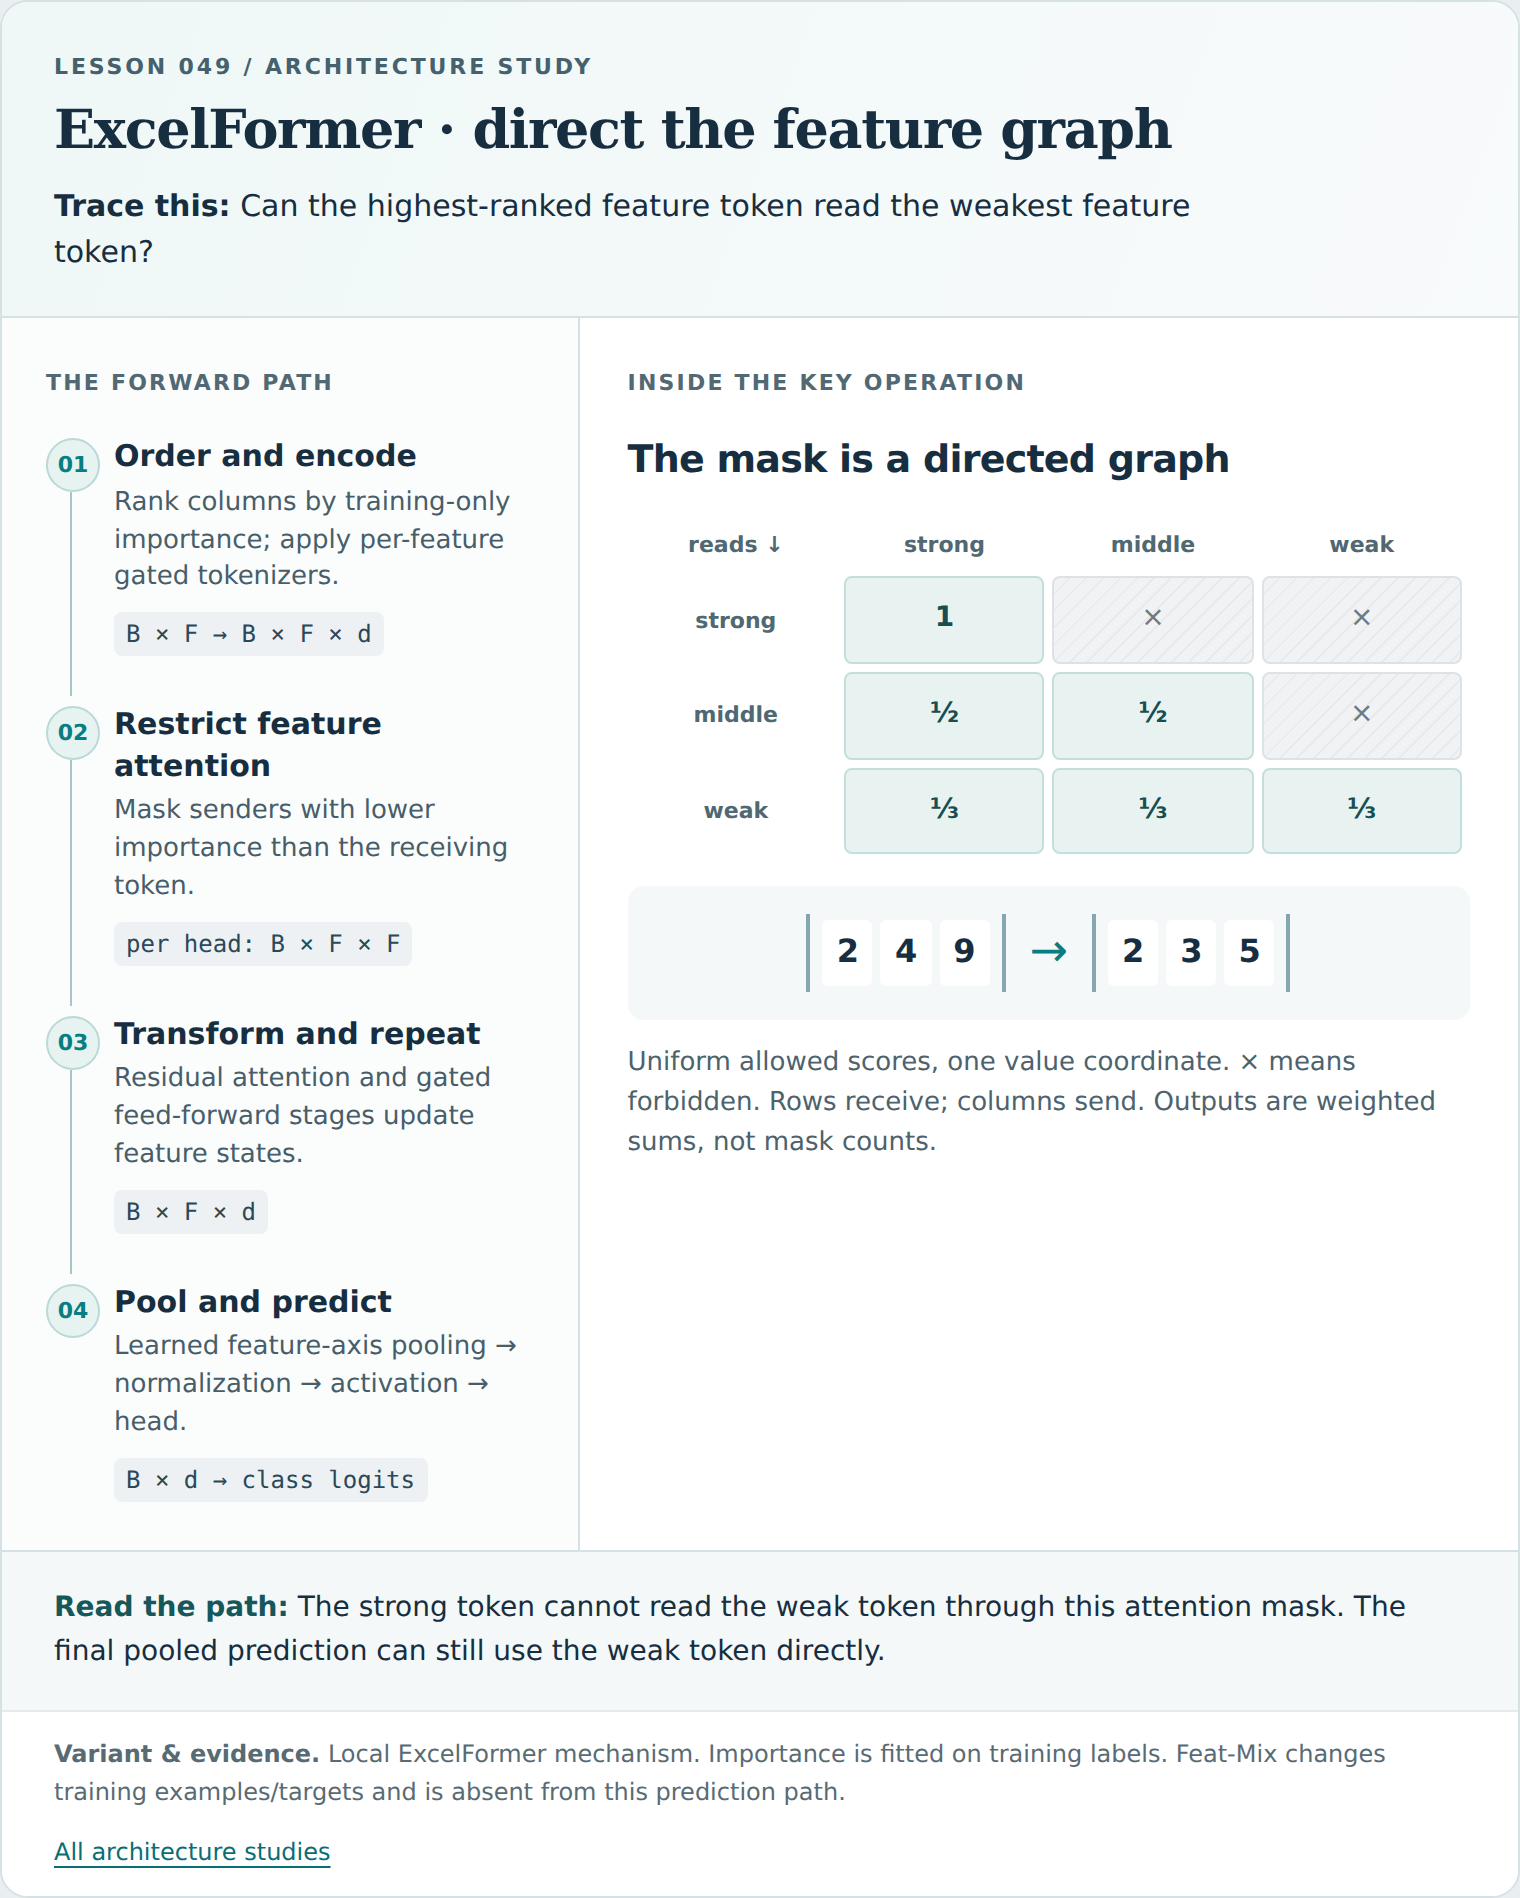</div>

*Portable architecture figure. On a narrow notebook screen, scroll horizontally to retain readable labels.* [Open the responsive diagram](https://avistian.github.io/relational/labs/html/architecture-review/0049-excelformer.html).

**Read the path:** The strong token cannot read the weak token through this attention mask. The final pooled prediction can still use the weak token directly.

**Variant and evidence:** Local ExcelFormer mechanism. Importance is fitted on training labels. Feat-Mix changes training examples/targets and is absent from this prediction path.

## 3. Semi-permeable attention: trace the direction




Ordinary attention forms a query Q for each receiver, a key K for each sender, and a value V to transmit. For one head of width dₕ, similarities are QKᵀ/√dₕ. Softmax exponentiates the scores and divides by their sum across senders, giving nonnegative weights that sum to one. Multiplying these weights by V creates one weighted sum per receiver.




A = softmax(QKᵀ / √dₕ + M),   output = AV




**M is a permission mask.** The paper blocks position (i,j) when feature i is more informative than feature j. Row i is the receiver; column j is the sender. The blocked route is therefore **weaker sender → stronger receiver**. With features sorted strongest first, the released implementation allows j≤i, a lower triangle including the diagonal. One broad sentence in the introduction reverses the verbal direction; Eq.2, its adjacent explanation, and the released mask agree on this interpretation. [§3.1, Eq.1–2](https://arxiv.org/html/2301.02819v5#S3.SS1); [pinned released code](https://github.com/WhatAShot/ExcelFormer/blob/17f70526390e70390bb8c8ec3850697eb730f9cd/bin/excel_former.py).




**Mutual information (MI)** measures statistical dependence: how much observing a feature reduces uncertainty about the target. Here it is an estimated, univariate, training-set statistic, not a causal effect or a guarantee of usefulness in interactions. The mask is fixed after fitting the training ordering; attention weights inside allowed positions remain learned and row-dependent. Never estimate this ordering from validation/test labels.




**Predict:** with equal logits and values [2,4,9], what happens to the strongest receiver if the last value doubles? Test your answer below, then remove the mask while keeping the logits fixed.





The masked outputs are [2,3,5]: the first receiver reads only 2, the second averages 2 and 4, and the third averages all three. Changing 9→18 gives [2,3,8]. Without the mask, every output changes from 5→8. These are synthetic arithmetic examples, not learned importance scores. The final model still pools the weak token, so its prediction can change even when the strong token’s attention output cannot.





**Ties require a declared choice.** Eq.2 permits both directions between equal-importance features. The released positional triangle selects one direction even for ties. We reproduce that positional behavior after stable sorting and record it as a paper/code distinction. With noisy MI estimates, a tiny change in ordering can change the allowed graph.





**Interaction-attenuated initialization** starts mixing weights small so the residual path initially dominates. Multiplying a weight’s standard deviation by 0.01 multiplies its variance by 0.0001. The paper describes attenuating SPA broadly; the released code attenuates Q/K/V and the gated update, while its attention output projection has ordinary initialization. The local model follows the released path. Neither small initial weights nor a triangular mask proves eventual generalization superiority.

### Interpret the mask as a directed information graph

Index features after sorting their training-derived importance from strongest to weakest. An attention score matrix has receivers on its rows and candidate senders on its columns. In the checked positional implementation, receiver i may read senders at positions j≤i. The resulting lower-triangular allow-pattern means that weaker positions can read stronger positions, while stronger positions cannot read weaker positions through this particular attention operation.

For three equally scored feature tokens with scalar values `[2,4,9]`, the first receiver sees only `[2]` and returns 2. The second sees `[2,4]` and returns 3. The third sees all three and returns 5. Change the weak value 9 to 18 while holding the keys and queries fixed: the outputs become `[2,3,8]`. The protected receiver outputs are unchanged because the altered sender is outside their permitted source sets. This is a statement about an operation and a controlled intervention, not a claim that the model's final prediction is independent of weak features.

The final pooling operation still has a route from every feature token. Moreover, subsequent transformations can combine available representations. A blocked attention edge is therefore narrower than global feature removal. To test whether a feature affects a final prediction, trace every route by which it can reach the head. The local mask CHECK should be paired with a full-model feature intervention if the desired claim concerns predictions.

### Why importance estimation belongs inside fitting

Mutual information measures statistical dependence between a feature and the target. For discrete variables, it compares the joint distribution with the distribution that would exist if feature and target were independent: terms of the form `p(x,y) log[p(x,y)/(p(x)p(y))]` are added across outcomes. Independent variables have zero population mutual information. Estimating this quantity from a finite sample requires additional choices, especially for continuous values, and estimated rankings can be noisy.

Because the target participates in that calculation, sorting columns by mutual information is supervised preprocessing. A sorting order estimated from all rows has already used held-out labels. Recomputing it independently within each training split is necessary even though the later Transformer itself never receives those held-out labels. A preprocessing function can leak information just as a fitted model can.

Importance is also marginal here: it considers a feature's relationship with the target under a specified estimator. Two features can be useful jointly while appearing weak separately. The order is therefore a modeling preference rather than an oracle ordering of true causal relevance. If nearly tied importance estimates swap order, the positional mask can change abruptly. The published equality rule and the checked release's stable positional tie handling should remain distinct in the reproduction ledger.

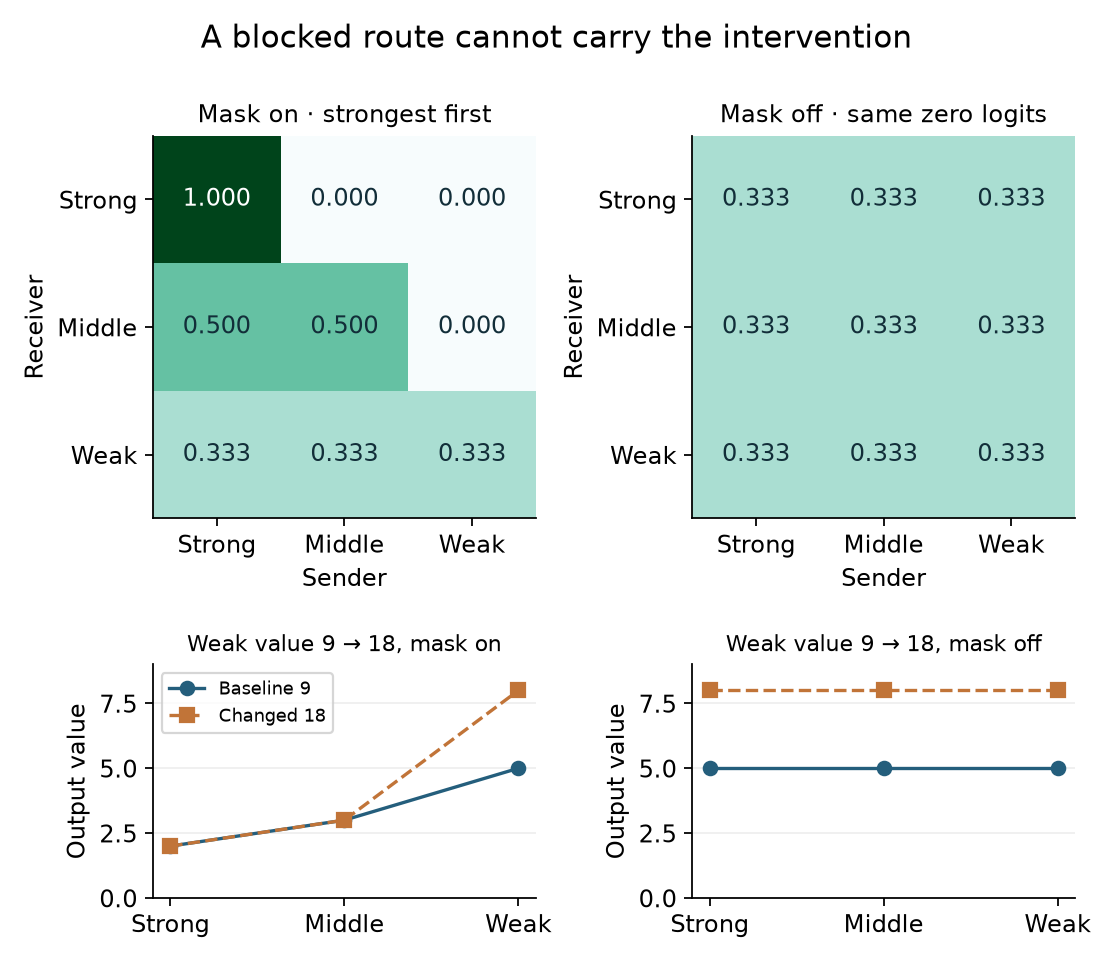

Synthetic intervention: keep equal logits; change weak value 9→18; compare the same receivers with and without masking.

### Task 1 — encode a permission rule
**Why:** a transposed mask can pass every shape check while implementing the opposite model. Inputs have shape [...,C,d_head]. Columns arrive strongest first. Compute scores, block weaker senders, normalize over senders, and return the weighted values plus the pre-dropout attention matrix. Keep dropout behavior provided below.

In [ ]:
# TODO — ExcelFormer Eq.1/2, released positional tie convention.
def spa_attention(q, k, v, dropout=0., training=False):
    scores = ____
    blocked = ____  # boolean [receiver, sender]
    weights = ____
    return F.dropout(weights, dropout, training) @ v, weights

In [ ]:
# CHECK — values, direction, and forbidden gradient pathway.
q=torch.zeros(1,3,2,dtype=torch.double)
v=torch.tensor([[[2.,0.],[4.,0.],[9.,0.]]],dtype=torch.double,requires_grad=True)
z,a=spa_attention(q,q,v)
assert torch.allclose(z[0,:,0],torch.tensor([2.,3.,5.],dtype=torch.double)), 'Inspect sender/receiver orientation.'
assert torch.allclose(a.sum(-1),torch.ones(1,3,dtype=torch.double)), 'Normalize senders, not receivers.'
z[0,0,0].backward()
assert torch.equal(v.grad[0,:,0],torch.tensor([1.,0.,0.],dtype=torch.double)), 'Weak values must have zero path into strong attention output.'
print('CHECK 1 passed: outputs and blocked gradients agree.')

### Read the complete model
These PROVIDED chunks form the model you will train. The block calls **your** `spa_attention`. Tokenization is a featurewise gated map; attention is the only token-mixing operation inside each block. The head subsequently pools all columns, so it can still read a weak feature.

In [ ]:
# PROVIDED — numeric feature embeddings — §3.2
class GatedTokenizer(nn.Module):
    def __init__(self, features, d):
        super().__init__()
        for name in ('weight', 'weight2', 'bias', 'bias2'):
            p = nn.Parameter(torch.empty(features, d))
            nn.init.kaiming_uniform_(p, a=math.sqrt(5))
            setattr(self, name, p)

    def forward(self, x):
        a = x[..., None]*self.weight + self.bias
        b = x[..., None]*self.weight2 + self.bias2
        return a * torch.tanh(b)

In [ ]:
# PROVIDED — attention residual followed by gated residual — released forward path
class SPABlock(nn.Module):
    def __init__(self, d, heads, dropout, scale, first):
        super().__init__()
        assert d % heads == 0
        self.heads, self.dropout = heads, dropout
        self.q, self.k, self.v = [nn.Linear(d, d) for _ in range(3)]
        self.out = nn.Linear(d, d) if heads > 1 else nn.Identity()
        self.gate = nn.Linear(d, 2*d)
        self.norm0 = nn.Identity() if first else nn.LayerNorm(d)
        self.norm1 = nn.LayerNorm(d)
        for layer in (self.q, self.k, self.v, self.gate):
            with torch.no_grad(): layer.weight.mul_(scale)
            nn.init.zeros_(layer.bias)
        if heads > 1: nn.init.zeros_(self.out.bias)

    def forward(self, x):
        b, c, d = x.shape
        z = self.norm0(x)
        q, k, v = [layer(z).reshape(b,c,self.heads,d//self.heads).transpose(1,2)
                   for layer in (self.q,self.k,self.v)]
        update, _ = spa_attention(q,k,v,self.dropout,self.training)
        x = x + self.out(update.transpose(1,2).reshape(b,c,d))
        a, gate = self.gate(self.norm1(x)).chunk(2, dim=-1)
        return x + a * torch.tanh(gate)

In [ ]:
# PROVIDED — complete prediction path; no model package hidden behind this cell
class ExcelFormer(nn.Module):
    """Numeric, pre-norm released variant; logits for binary classification.

    Lab defaults shrink width/depth. Released implementation scales Q/K/V and
    GLU weights; the attention output map uses ordinary Kaiming initialization.
    """
    def __init__(self, features, d=32, heads=4, layers=2, dropout=.1, scale=.01):
        super().__init__()
        self.tokenizer = GatedTokenizer(features,d)
        self.blocks = nn.ModuleList([SPABlock(d,heads,dropout,scale,i==0) for i in range(layers)])
        self.pool = nn.Linear(features,1)
        self.norm = nn.LayerNorm(d)
        self.act = nn.PReLU()
        self.head = nn.Linear(d,1)

    def forward(self,x,mix=None):
        z = self.tokenizer(x)
        if mix is not None: z = mix(z)
        for block in self.blocks: z = block(z)
        z = self.pool(z.transpose(1,2)).squeeze(-1)
        return self.head(self.act(self.norm(z))).squeeze(-1)

In [ ]:
# CHECK — validate your visible model against the canonical implementation.
from relkit.claim_models import ExcelFormer as CanonicalExcel
from relkit.claim_models import spa_attention as canonical_attention

torch.manual_seed(49)
visible=ExcelFormer(5,d=16,heads=2,layers=2,dropout=0).double().eval()
reference=CanonicalExcel(5,d=16,heads=2,layers=2,dropout=0).double().eval()
reference.load_state_dict(visible.state_dict())
x=torch.randn(7,5,dtype=torch.double,requires_grad=True)
xref=x.detach().clone().requires_grad_()
a,b=visible(x),reference(xref)
assert torch.allclose(a,b,atol=1e-10,rtol=1e-10),'Your model differs from the equation-checked canonical path.'
a.sum().backward();b.sum().backward()
assert torch.allclose(x.grad,xref.grad,atol=1e-10,rtol=1e-10),'Input gradient mismatch.'
released=json.loads(Path('_reference_l049_results.json').read_text())
print('Your model matches the canonical path. Separate pinned released-code check:',released)
# The released-code artifact validates canonical code; this cell separately validates your code.

## 4. Feat-Mix: which donor supplies the information?




**Data augmentation** creates modified training examples. Feat-Mix swaps whole feature tokens between two donor rows. Let mᵢ=1 retain feature i from row A and mᵢ=0 take it from B. If Iᵢ is that feature’s nonnegative training MI, the share assigned to A is:




λ = Σᵢ mᵢIᵢ / Σᵢ Iᵢ,   ỹ = λyA + (1−λ)yB




For MI values [6,3,1], keeping only the first feature gives λ=0.6, not 1/3. If donor labels are 1 and 0, the mixed target is 0.6. A **soft target** between zero and one is permitted by binary cross-entropy. It represents a training heuristic; it is not a newly observed outcome. [§4, Eq.7–8](https://arxiv.org/html/2301.02819v5#S4).





Our sampler draws a retention probability from Beta(0.5,0.5), then independent Bernoulli choices per row and feature. Beta here is a distribution over probabilities; its two parameters favor extreme retention shares. This is a documented sampler choice, not a verified match to every detail of the released augmentation code. If total MI is zero, Eq.8 has a zero denominator; the lab explicitly falls back to the retained-feature fraction.




**Hid-Mix**, the paper’s other augmentation, exchanges embedding coordinates across donors, applying the same coordinate mask across feature tokens. Its label interpolation differs from Feat-Mix’s information weighting. We explain the distinction but do not implement or evaluate Hid-Mix today. Do not label our Feat-Mix result as the paper’s “Hid-Mix,” “Mix Tuned,” or “Fully Tuned” result.




Both augmentations are training-only. No donor row or label is needed at inference. This differs from SAINT’s inference-time companion context and from reading a relational neighborhood at prediction time.

### The feature mask and target mixture must describe the same donors

Consider donor A with label 1 and donor B with label 0. A mask chooses which entire feature tokens come from A. If the three feature-importance weights are `[6,3,1]` and only the first feature comes from A, A supplies 6 of the total 10 importance units. The mixed target is therefore 0.6. Taking one of three columns does not imply a target of one third when the augmentation explicitly uses importance-weighted contributions.

A soft target of 0.6 is not an observed new event whose true class has somehow become fractional. It is the training objective's prescribed interpolation between two labeled examples. Binary cross-entropy accepts such a target because it is linear in the target value: the loss for target 0.6 is the same weighted combination of the positive-label and negative-label losses. This makes the target mixture mathematically well defined without proving that the mixed feature vector follows the real data-generating process.

There are two important consistency checks. First, the permutation used to choose B must be identical in the feature-mixing and target-mixing paths. Second, the mask used to compute the target weight must be the mask actually used to choose the tokens. Independent random draws in these two paths can produce perfectly valid shapes and a decreasing loss while teaching the wrong donor correspondence.

What if every importance estimate is zero? The weight formula has a zero denominator. The notebook states a count-based fallback, so the operation remains executable and its changed assumption is visible. An alternative would be to disable the augmentation for that task. Either policy requires a deliberate choice; silently returning NaN, inventing a nonzero importance total, or discarding examples after seeing their outcomes changes the experiment without explaining why.

Finally, distinguish embedding-space replacement from interpolation of raw feature values. Exchanging one learned token preserves its donor identity at that stage. Interpolating a category ID as if it were a measured magnitude is a different and usually meaningless operation. The model's tokenizer and the location of augmentation determine what object is actually being mixed.

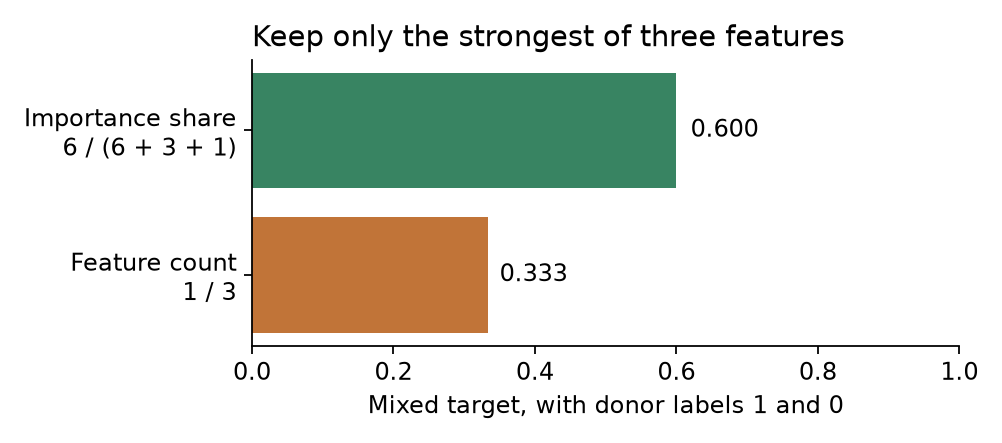

Synthetic donors 1 and 0: retaining feature importance 6 out of 10 gives target 0.600, versus count-based 0.333.

### Task 2 — make the label follow the retained information
**Why:** swapping tensors correctly while mixing labels by the wrong share changes the learning objective. A boolean mask [B,C] chooses donor A. Handle zero total importance explicitly; the fallback is the retained-feature fraction.

In [ ]:
# TODO — ExcelFormer Eq.7/8, plus an explicit zero-information fallback.
def feat_mix(tokens, y, importance, mask, permutation):
    total = importance.sum()
    ratio = ____ if total > 0 else ____
    mixed = ____
    return mixed, ratio*y + (1-ratio)*y[permutation]

In [ ]:
# CHECK — mixed values, targets, all-retained, and zero-information behavior.
tokens=torch.arange(12.).reshape(2,3,2);y=torch.tensor([1.,0.]);imp=torch.tensor([6.,3.,1.]);perm=torch.tensor([1,0])
mask=torch.tensor([[True,False,False],[True,False,False]])
mixed,target=feat_mix(tokens,y,imp,mask,perm)
assert torch.allclose(target,torch.tensor([.6,.4])), 'Weight labels by retained MI.'
assert torch.equal(mixed[:,0],tokens[:,0]) and torch.equal(mixed[:,1:],tokens[perm,1:]), 'Check donor direction.'
_,all_y=feat_mix(tokens,y,imp,torch.ones_like(mask),perm)
assert torch.equal(all_y,y)
_,zero_y=feat_mix(tokens,y,torch.zeros(3),mask,perm)
assert torch.allclose(zero_y,torch.tensor([1/3,2/3])), 'Zero total MI needs a finite declared fallback.'
print('CHECK 2 passed.')

### Read the learning loop
Validation log loss selects the checkpoint. Test labels are never used inside this loop. Feat-Mix runs only in training; prediction applies sigmoid to logits. Small initialized mixing weights are not frozen: optimizer updates can change them.

In [ ]:
# PROVIDED — training, optional Feat-Mix, validation selection, checkpoint restore
def train_excel(model, x, y, train, valid, *, seed=0, epochs=30, lr=.001,
                batch=64, patience=12, augmentation=False, importance=None, device='cpu'):
    """Visible learning loop: select checkpoint using validation log loss only."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model = model.to(device)
    xt = torch.as_tensor(x,dtype=torch.float32,device=device)
    yt = torch.as_tensor(y,dtype=torch.float32,device=device)
    imp = torch.as_tensor(importance,dtype=torch.float32,device=device) if importance is not None else None
    optimizer = torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=0)
    best, best_state, stale, history = float('inf'), None, 0, []
    for epoch in range(epochs):
        model.train()
        for ids in np.array_split(rng.permutation(train), max(1,math.ceil(len(train)/batch))):
            target = yt[ids]
            mix = None
            if augmentation:
                keep = rng.beta(.5,.5)
                mask = torch.rand((len(ids),x.shape[1]),device=device) < keep
                perm = torch.randperm(len(ids),device=device)
                # Compute targets via the SAME primitive that mixes embeddings.
                _, target = feat_mix(xt[ids,...,None],target,imp,mask,perm)
                mix = lambda z: feat_mix(z,yt[ids],imp,mask,perm)[0]
            logits = model(xt[ids],mix=mix)
            loss = F.binary_cross_entropy_with_logits(logits,target)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            score = float(F.binary_cross_entropy_with_logits(model(xt[valid]),yt[valid]))
        history.append({'epoch':epoch+1,'valid_log_loss':score})
        if score < best:
            best,best_state,stale = score,copy.deepcopy(model.state_dict()),0
        else: stale += 1
        if stale >= patience: break
    model.load_state_dict(best_state)
    model.eval()
    return model,history

In [ ]:
# PROVIDED — batched, independent-row inference
@torch.no_grad()
def predict_excel(model,x,batch=1024):
    device = next(model.parameters()).device
    return np.concatenate([torch.sigmoid(model(torch.as_tensor(a,dtype=torch.float32,device=device))).cpu().numpy()
                           for a in np.array_split(x,max(1,math.ceil(len(x)/batch)))])

## 5. Model architecture — Trompt




Trompt uses learned **column embeddings** to represent table structure and learned **prompt embeddings** to query that structure. These are trainable vectors, not text instructions. There is no pretrained language model in this architecture. Both embedding sets are shared across input rows; dependence on an individual row enters through the previous cell’s representation. [§3](https://arxiv.org/html/2305.18446v2#S3).




A cell fuses the broadcast prompt Eₚ with the preceding output Oprev:




H = dense(concat(Eₚ, Oprev)) + Eₚ + Oprev  
M = softmax(H Ecolumnᵀ)   [B,P,C]




Concatenation puts two d-wide vectors side by side; the dense map reduces 2d back to d. Each prompt then scores every column. Softmax runs over **C, the column axis**, so each prompt gets its own distribution over columns. The paper’s Eq.4 does not divide these scores by √d; importing that factor from Transformer attention would change the specified operation. The weights can be row-specific because H can be row-specific, even though Ecolumn is shared.




Each Trompt cell reads the original row again. Numeric values pass through per-column affine maps, ReLU and LayerNorm; categorical values would use embedding lookups and LayerNorm (omitted in the numeric lab). A learned expansion, ReLU, GroupNorm and residual produce Ê [B,P,C,d]. The notebook implements this entire numeric cell, including the prompt fusion and shared downstream head.




O[b,p,k] = Σc M[b,p,c] × Ê[b,p,c,k]   → [B,P,d]




Indices b,p,c,k identify a row, prompt, column and embedding coordinate. The sum removes the column axis. It preserves the prompt axis, letting different prompts retain different summaries. These are the two live implementation exercises: compute M correctly, then sum the weighted expanded features over the correct axis. [§3.1, Eq.1–5](https://arxiv.org/html/2305.18446v2#S3.SS1).





In this worked example, column vectors are [1,0], [0,1], [0,0] and one fused query is [t,0]. At t=0 the weights are uniform and the output from values [2,4,9] is 5. At t=2 the logits are [2,0,0], the weights are approximately [0.787,0.107,0.107], and the output is 2.959. Numbers displayed to three decimals are rounded; computations use full precision.




**First-cell subtlety:** §5.1 specifies Oprev=0. Thus the first cell has identical column-routing weights across rows, although its aggregated values and predictions can differ. Later cells receive row-dependent state. The lab follows the paper’s zero state; the pinned independent PyTorch Frame implementation uses a learned initial state. These are different full-model variants, even when component outputs match.




The downstream head uses another softmax, this time over **P, the prompt axis**, to combine prompt representations. Two dense layers with ReLU and LayerNorm (Fig.4) produce class scores. The same downstream module serves multiple cells. Training sums the individual cell losses; inference averages cell predictions in Eq.9. The lab now implements the full numeric scheme, with the exact normalization and aggregation conventions described below. [§3.2](https://arxiv.org/html/2305.18446v2#S3.SS2).

<div style="overflow-x:auto;max-width:100%">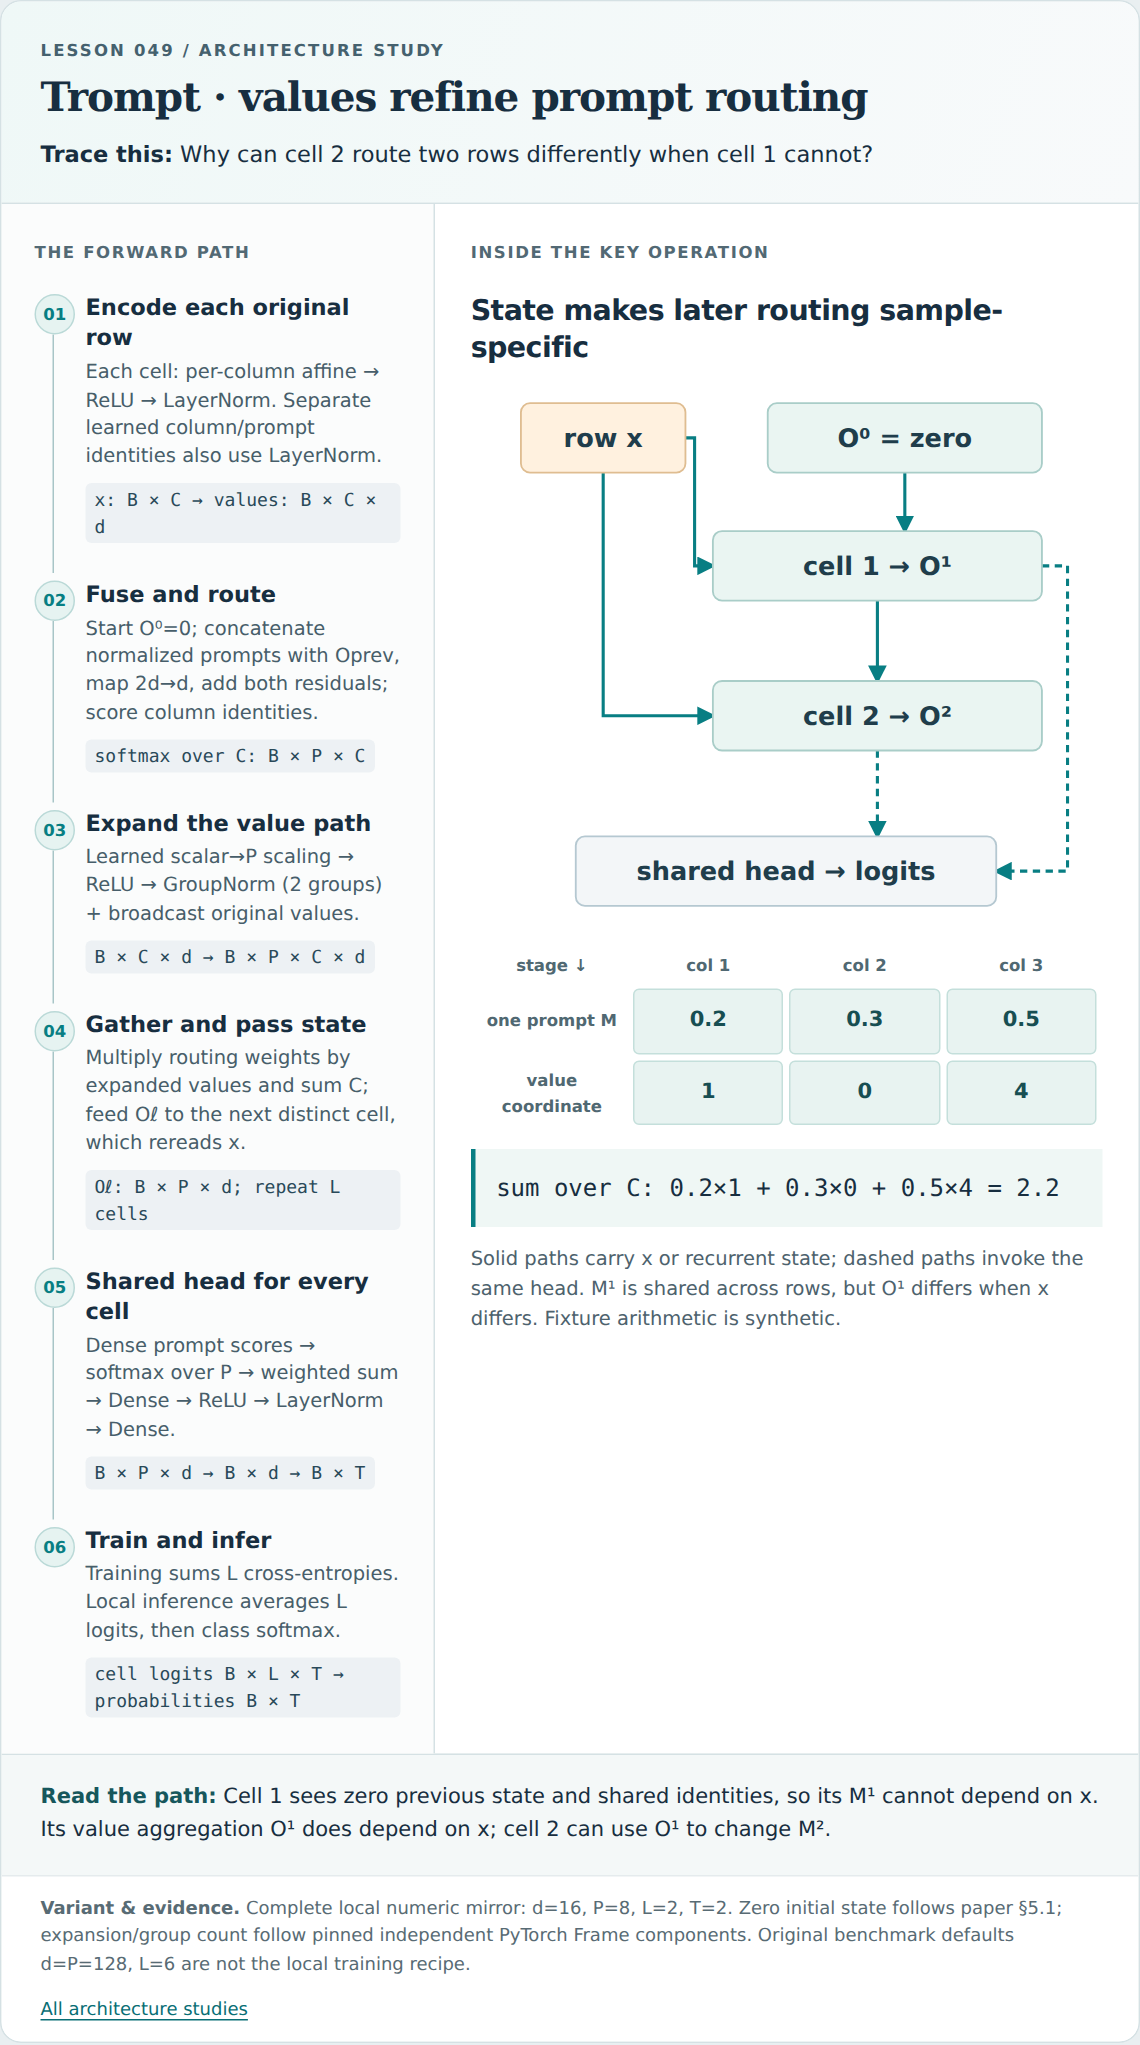</div>

*Portable architecture figure. On a narrow notebook screen, scroll horizontally to retain readable labels.* [Open the responsive diagram](https://avistian.github.io/relational/labs/html/architecture-review/0049-trompt.html).

**Read the path:** Cell 1 sees zero previous state and shared identities, so its M¹ cannot depend on x. Its value aggregation O¹ does depend on x; cell 2 can use O¹ to change M².

**Variant and evidence:** Complete local numeric mirror: d=16, P=8, L=2, T=2. Zero initial state follows paper §5.1; expansion/group count follow pinned independent PyTorch Frame components. Original benchmark defaults d=P=128, L=6 are not the local training recipe.

### A prompt is a learned aggregation slot

Here “prompt” does not mean a sentence given to a language model. It is a learned vector that participates in a tabular representation computation. Several prompts can specialize in different combinations of columns. The full model updates prompt-related state through its cells, and the notebook now connects those operations to that complete numeric computation.

Let B be the number of rows, P the number of prompts, C the number of columns, and d the embedding width. Fused prompt vectors have shape `[B,P,d]`; column-identity vectors have shape `[C,d]`. Their dot products produce `[B,P,C]` scores. Applying softmax along C gives one distribution over columns for each row and each prompt. Normalizing over P instead would answer a different question: allocating each column among prompts rather than letting each prompt choose its contributing columns.

The feature values follow another path to a tensor of shape `[B,P,C,d]`. Multiply each feature vector by its matching scalar weight, then sum over C. The result has shape `[B,P,d]`: one vector per row and prompt. For one prompt, weights `[0.2,0.3,0.5]` and feature vectors `[1,0]`, `[0,2]`, `[4,1]` give `[2.2,1.1]`. Summing over d instead would collapse the embedding and retain the wrong axis, even though the result might still be a legal array for some later operation.

The distinction between column identities and feature values is central. The identity path describes which kind of field a token belongs to; the value path contains the row-specific information to aggregate. The full paper includes feature expansion, normalization, residual connections, and repeated cell behavior beyond the two equations. The reduction fixture above isolates an axis; the complete TromptCell below learns its expanded features instead of using that fixture as a model.

### Build the missing paths in the Trompt cell

A useful prediction example is a table with employment type, monthly salary and business revenue. A salaried row and a self-employed row may need different mixtures of evidence. A single fixed feature ranking cannot express that distinction by itself. Trompt's learned column vectors describe fields shared across rows; the recurrent prompt state lets the mixture change by row. This is a modeling motivation, not evidence that a prompt has discovered a causal customer category.

In cell ℓ, normalize the learned prompt and column vectors over their d coordinates. LayerNorm subtracts a vector's coordinate mean and divides by the square root of its coordinate variance plus ε, then applies learned scale and shift. It does not normalize across rows. Broadcast the normalized prompts to [B,P,d]. Concatenate each prompt with Oprev to get [B,P,2d], apply a 2d→d dense map, and add both inputs back. These residual additions preserve direct paths for shared prompt identity and previous row-specific state. Then compute the unscaled dot products and softmax over columns as in the worked example. A dot product is not automatically cosine similarity: cosine also divides by vector norms; even normalized inputs and learned affine parameters do not justify silently changing this equation.

The value path is independent of these column-identity vectors. For numeric feature c, `x_c w_c + b_c` creates d coordinates, ReLU clips negative coordinates to zero, and LayerNorm rescales the resulting vector. Each cell has its own numeric encoder. Input x enters every cell; only Oprev flows recurrently from one cell to the next. Replacing later x inputs with the previous state's P prompt vectors would confuse the column and prompt axes.

The expansion path creates a different feature representation for each prompt. In our declared implementation, a bias-free 1→P map multiplies each scalar feature coordinate e by a learned prompt coefficient a_p. ReLU then gives max(0,a_p e). GroupNorm divides the P prompt channels into two groups and, within each row and group, normalizes over the group's prompt channels, C columns and d coordinates. Its learned affine transformation acts per prompt channel. Add the original feature embedding, broadcast over P, to this normalized update. The resulting Ê has shape [B,P,C,d]. The group count and bias-free scalar expansion follow the pinned independent PyTorch Frame component; the paper's figure names Dense/ReLU/GroupNorm but does not uniquely specify these implementation details.

Notice the residual's purpose. Even if the expansion update vanishes, the original row values still reach every prompt. Conversely, learned expansion means two prompts with identical column weights can produce different summaries. If e contains [−2,1], prompt coefficients +1 and −1 produce pre-normalization ReLU values [0,1] and [2,0]. Merely copying [−2,1] twice cannot express this intervention. The lab checks both the learned difference and the gradients into its coefficients. GroupNorm also couples columns in this value path: a small routing weight is not proof of zero influence on the final prediction.

### Follow two cells all the way to a supervised prediction

The first previous state is zero, as specified in §5.1. Consequently its fused queries depend only on trained parameters; both rows receive the same first-cell M. Their numeric values differ, so the first outputs O¹ can differ. Cell two fuses O¹ with its own prompts, allowing M² to differ by row. This is the first route that makes the routing matrix sample-specific. It does not require information from a second batch row. The notebook runs the actual two-cell model on rows together and separately to check this distinction from SAINT's intersample attention.

A shared downstream head receives every Oℓ [B,P,d]. It scores each prompt using a d→1 dense map and softmax over **P**, then sums prompt states to [B,d]. This is a second, different softmax from the cell's column softmax. A d→d dense layer, ReLU, LayerNorm (visible in Fig.4), and d→T dense layer produce T class logits. A logit is an unconstrained class score; softmax converts all T logits to class probabilities. The small binary lab uses T=2, while ExcelFormer uses a single binary logit and sigmoid. Their numerical losses are comparable only after accounting for these conventions.

For L cells, training sums each cell's mean-over-rows cross-entropy. This gives early cells their own prediction objective while later losses also backpropagate through earlier state. It is not L independent models: cells are connected, and the head's parameters are shared. Nor is it cross-entropy of an averaged output. For a binary target 1 and two positive-class probabilities .9 and .1, the two losses sum to −log(.9)−log(.1)≈2.408, whereas the loss of their average probability .5 is ≈.693. These objectives send different gradients.

The paper's Eq.8 outputs dense scores and Eq.9 averages predictions. Our numeric convention explicitly averages the cell logits and then applies class softmax; averaging already-normalized probabilities would be another choice. The lab's validation checkpoint minimizes cross-entropy of those averaged logits. It uses AdamW, a fixed learning rate, and a small epoch cap: this is the local recipe, not a reconstructed Grinsztajn45 training/search procedure. The standalone component parity check validates encoded-value cell operations and the head against pinned PyTorch Frame source with copied weights. It does not validate the full author implementation, which was not identified, or make PyTorch Frame's learned initial state equal to the paper's zero state.

### Read Trompt's ablations as interventions

Section 4.3 Table 4 compares learned expansion with its removal. Classification changes from 81.81% to 80.76%, while regression changes from 74.15% to 73.73% in that ablation setting. These are published aggregate metrics, not the notebook's measurements. The intervention changes the ability to provide prompt-specific feature representations; it does not isolate the effect of “using prompts” from every other component. Table 3 compares prompt counts 1, 64, 128 and 256; its main contrast is a single prompt versus many, not monotonic improvement with every extra prompt. Appendix D.1 Table 25 separately varies cell count: one cell lacks sample-specific routing, though its value path still depends on x.

There is a subtle protocol distinction in Appendix C: regression ablations use standardized targets because that choice performed better, whereas §4.2 keeps the benchmark's quantile-target transformation. Thus 74.15% from the ablation is not a drop-in baseline for a benchmark score with different preprocessing. Before attributing a gain to expansion, hold the target transformation fixed. The local Pima probe measures execution and held-out prediction of the full numeric model; it does not reproduce any of these ablation rows or justify ranking Trompt against the existing ExcelFormer table.

### What a feature-importance picture does and does not explain

Trompt Eq.10 combines each cell's column weights using that cell's downstream prompt weights, then the paper averages across cells. This is a descriptive summary of learned routing. It is not a derivative, an intervention effect, or an identification of causes. Values can be transformed differently for different prompts, GroupNorm couples the expanded values, and the head is nonlinear. Two equal routing scores can therefore accompany unequal effects on predictions. The paper checks masks on Syn2/Syn4 and feature rankings on mushroom; that evidence tests recovery in those constructed or selected settings. For a deployed relational prediction, perturb only information available at the query time and measure the output effect separately.

Sources for this complete trace: [Trompt v2 §3–5](https://arxiv.org/html/2305.18446v2#S3), [the published Fig.2–4 and appendices](https://proceedings.mlr.press/v202/chen23c/chen23c.pdf), and the [pinned independent cell implementation](https://github.com/pyg-team/pytorch-frame/blob/3ed76b132242be6ce5f63851052e114e57aaec5d/torch_frame/nn/conv/trompt_conv.py). All numerical examples above are worked calculations except the explicitly labeled paper table values.

![Synthetic one-prompt example: fixed column vectors and values, query changes [0,0]→[2,0]; output changes 5.000→2.959.](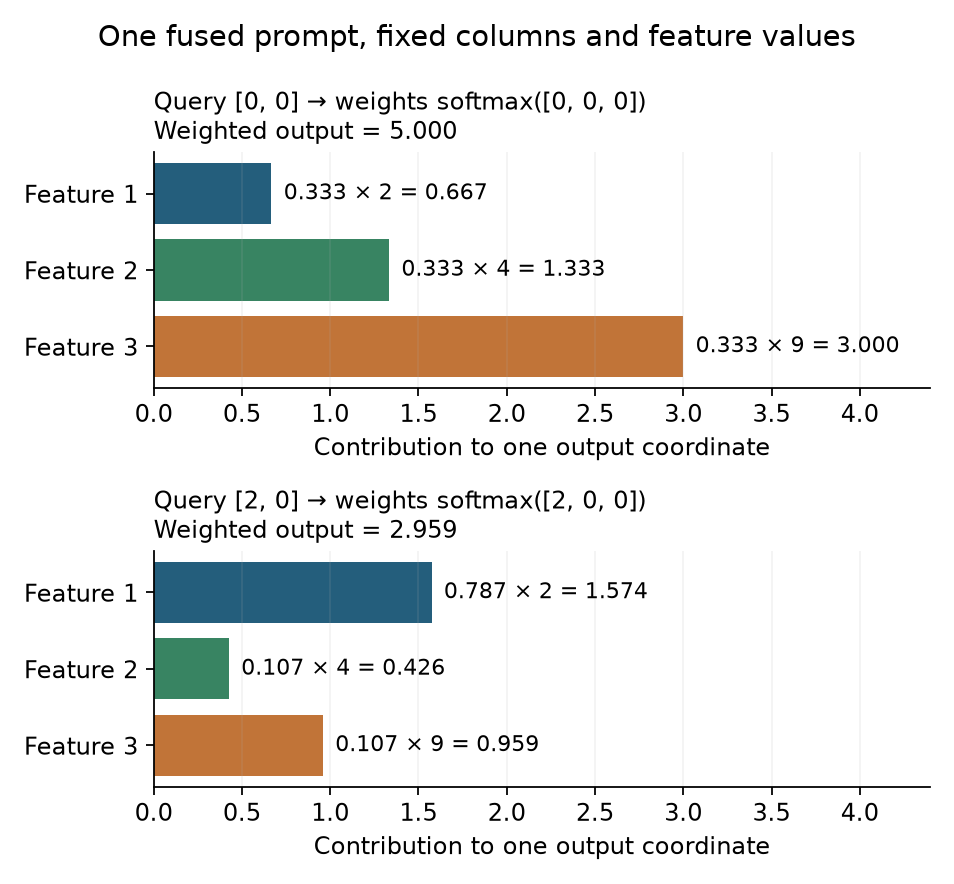)

Synthetic one-prompt example: fixed column vectors and values, query changes [0,0]→[2,0]; output changes 5.000→2.959.

### Task 3 — preserve the right axes
**Why:** mixing up columns and prompts yields plausible shapes in symmetric examples. Use unequal P and C in the checks. Implement Eq.4 with unscaled dot products, then Eq.5 on already-expanded features. The expansion tensor below is PROVIDED test data, not a replacement for the full paper’s learned expansion.

In [ ]:
# TODO — Trompt Eq.4 and Eq.5.
def prompt_weights(fused_prompts, columns):
    return ____

def prompt_reduce(weights, expanded_features):
    return ____

In [ ]:
# CHECK — non-square axes and controlled row-specificity.
columns=torch.tensor([[1.,0.],[0.,1.],[0.,0.]])
shared=torch.zeros(2,2,2)  # B=2, P=2, d=2; same initial fused query
w=prompt_weights(shared,columns)
assert w.shape==(2,2,3) and torch.allclose(w.sum(-1),torch.ones(2,2))
assert torch.equal(w[0],w[1]), 'Identical fused queries must produce identical weights.'
changed=shared.clone();changed[1,0,0]=2
wc=prompt_weights(changed,columns)
assert torch.allclose(wc[1,0],torch.tensor([.786986,.106507,.106507]),atol=1e-6), 'Eq.4 has no sqrt(d) divisor.'
values=torch.tensor([2.,4.,9.]).reshape(1,1,3,1).expand(2,2,3,2)
z=prompt_reduce(wc,values)
assert z.shape==(2,2,2), 'Sum columns C; preserve prompts P and coordinates d.'
assert abs(z[0,0,0].item()-5)<1e-6 and abs(z[1,0,0].item()-2.958563)<1e-5
assert torch.equal(z[0],prompt_reduce(wc[:1],values[:1])[0]), 'No cross-row information route.'
print('CHECK 3 passed. Changed query reweights columns without any other batch row.')

### Connect your routing operations to the full Trompt model
Read Fig.3 as three connected paths: learned column/prompt identities, the row's numeric values, and prompt-specific expansion. The classes below call **your** Task 3 functions on every cell. `groups=2` and bias-free scalar expansion match the pinned independent PyTorch Frame component. The zero initial state follows paper §5.1. The categorical encoder is outside this numeric variant.

In [ ]:
# PROVIDED — complete numeric Trompt: TromptCell
class TromptCell(nn.Module):
    """Separate column identities, row values, and recurrent prompt state."""
    def __init__(self, features, d, prompts, groups=2):
        super().__init__()
        if prompts % groups: raise ValueError('prompts must divide into GroupNorm groups')
        self.prompts=nn.Parameter(torch.randn(prompts,d)*.01)
        self.columns=nn.Parameter(torch.randn(features,d)*.01)
        self.prompt_norm=nn.LayerNorm(d)
        self.column_norm=nn.LayerNorm(d)
        self.fusion=nn.Linear(2*d,d)
        self.value_weight=nn.Parameter(torch.empty(features,d))
        self.value_bias=nn.Parameter(torch.zeros(features,d))
        nn.init.normal_(self.value_weight,std=.01)
        self.value_norm=nn.LayerNorm(d)
        self.expansion_weight=nn.Parameter(torch.randn(prompts)*.01)
        self.group_norm=nn.GroupNorm(groups,prompts)

    def forward(self,x,previous,return_trace=False):
        p=self.prompt_norm(self.prompts)[None].expand(len(x),-1,-1)
        fused=self.fusion(torch.cat([p,previous],dim=-1))+p+previous
        weights=prompt_weights(fused,self.column_norm(self.columns))
        values=self.value_norm(F.relu(x[...,None]*self.value_weight+self.value_bias))
        # Each scalar becomes P learned scalings. GroupNorm normalizes within
        # each row over (P/groups, C, d), with learned affine per prompt.
        expanded=F.relu(values[:,None]*self.expansion_weight[None,:,None,None])
        expanded=self.group_norm(expanded)+values[:,None]
        output=prompt_reduce(weights,expanded)
        if return_trace:return output,dict(weights=weights,expanded=expanded,output=output)
        return output

In [ ]:
# PROVIDED — complete numeric Trompt: TromptHead
class TromptHead(nn.Module):
    """One shared downstream head; softmax now reduces prompts P, not columns C."""
    def __init__(self,d,classes):
        super().__init__()
        self.prompt_score=nn.Linear(d,1)
        self.hidden=nn.Linear(d,d)
        self.norm=nn.LayerNorm(d)
        self.output=nn.Linear(d,classes)

    def forward(self,state):
        weights=self.prompt_score(state).softmax(dim=1)
        pooled=(weights*state).sum(dim=1)
        return self.output(self.norm(F.relu(self.hidden(pooled))))

In [ ]:
# PROVIDED — complete numeric Trompt: Trompt
class Trompt(nn.Module):
    """Return [B,L,T] logits; every cell rereads x and passes state to the next."""
    def __init__(self,features,d=16,prompts=8,layers=2,classes=2,groups=2):
        super().__init__()
        if layers<1:raise ValueError('at least one cell is required')
        self.d,self.num_prompts=d,prompts
        self.cells=nn.ModuleList([TromptCell(features,d,prompts,groups) for _ in range(layers)])
        self.head=TromptHead(d,classes)

    def forward(self,x,return_trace=False):
        state=x.new_zeros(len(x),self.num_prompts,self.d)
        logits,trace=[],[]
        for cell in self.cells:
            state,detail=cell(x,state,return_trace=True)
            logits.append(self.head(state));trace.append(detail)
        result=torch.stack(logits,dim=1)
        return (result,trace) if return_trace else result

### Task 4 — supervise every cell
**Goal:** implement Eq.9 for class logits [B,L,T] and integer labels [B]. **Why:** training only the last cell, or averaging the logits before the loss, changes the objective. **Hint:** each cell supplies one mean-over-rows classification loss; the cell axis is the second axis. Keep the downstream head shared.

In [ ]:
# TODO — Trompt Eq.9, deep supervision.
def trompt_loss(cell_logits, y):
    return ____

In [ ]:
# CHECK — distinguish sum of losses from loss of the averaged prediction.
a=torch.tensor([[[0.,2.],[0.,-2.]],[[1.,0.],[-1.,0.]]],requires_grad=True)
y=torch.tensor([1,0])
expected=F.cross_entropy(a[:,0],y)+F.cross_entropy(a[:,1],y)
assert torch.allclose(trompt_loss(a,y),expected), 'Sum the cell losses; do not average logits first.'
trompt_loss(a,y).backward()
assert a.grad[:,0].abs().sum()>0 and a.grad[:,1].abs().sum()>0
torch.manual_seed(49)
probe_model=Trompt(3,d=8,prompts=4,layers=2).double()
xx=torch.tensor([[1.,-2.,3.],[3.,1.,-1.]],dtype=torch.double)
logits,trace=probe_model(xx,return_trace=True)
assert torch.equal(trace[0]['weights'][0],trace[0]['weights'][1]), 'Zero initial state implies shared first-cell routing.'
assert not torch.allclose(trace[1]['weights'][0],trace[1]['weights'][1]), 'Previous row values should reach later routing.'
assert torch.allclose(logits,torch.cat([probe_model(row[None]) for row in xx]),atol=1e-10), 'Trompt must not read another batch row.'
assert not torch.allclose(trace[0]['expanded'][:,0],trace[0]['expanded'][:,1]), 'Learned expansion must permit different prompt values.'
trompt_loss(logits,torch.tensor([0,1])).backward()
assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in probe_model.parameters())
print('CHECK 4 passed: complete cell recurrence, expansion, and supervised gradients.')
print('Separate pinned independent component check:',json.loads(Path('_reference_trompt_l049_results.json').read_text()))

### Train and infer using the declared aggregation rule
The training loop sums cell cross-entropies. Validation scores the mean logits, and restores the checkpoint with lowest validation cross-entropy. Inference averages logits then applies class softmax. The paper does not supply an author implementation here; this precise convention and the local optimizer recipe are disclosed rather than implied by the name Trompt.

In [ ]:
# PROVIDED — train_trompt
def train_trompt(model,x,y,train,valid,*,seed=49,epochs=20,batch=64,lr=.001,patience=8,device='cpu'):
    """Local fixed recipe; checkpoint chosen by validation CE of mean logits."""
    torch.manual_seed(seed);rng=np.random.default_rng(seed)
    model=model.to(device)
    xt=torch.as_tensor(x,dtype=torch.float32,device=device)
    yt=torch.as_tensor(y,dtype=torch.long,device=device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=0)
    best,best_state,stale,history=float('inf'),None,0,[]
    for epoch in range(epochs):
        model.train()
        for ids in np.array_split(rng.permutation(train),max(1,math.ceil(len(train)/batch))):
            loss=trompt_loss(model(xt[ids]),yt[ids])
            optimizer.zero_grad();loss.backward();optimizer.step()
        model.eval()
        with torch.no_grad():score=float(F.cross_entropy(model(xt[valid]).mean(1),yt[valid]))
        history.append({'epoch':epoch+1,'valid_log_loss':score})
        if score<best:best,best_state,stale=score,copy.deepcopy(model.state_dict()),0
        else:stale+=1
        if stale>=patience:break
    model.load_state_dict(best_state);model.eval()
    return model,history

In [ ]:
# PROVIDED — predict_trompt
@torch.no_grad()
def predict_trompt(model,x,batch=256):
    """Chosen Eq.9 convention: average cell logits, then class softmax."""
    device=next(model.parameters()).device
    return np.concatenate([model(torch.as_tensor(a,dtype=torch.float32,device=device)).mean(1).softmax(-1).cpu().numpy()
        for a in np.array_split(x,max(1,math.ceil(len(x)/batch)))])

### Run the separate Trompt execution probe
**Predict first:** will the first routing matrix vary by row after training, or will only later matrices vary? Train three small models on the released Pima split. This is a working-model test on ExcelFormer's data release, not a Trompt benchmark reproduction or a fourth arm in the earlier comparison. The reported SD measures three training seeds on one fixed split.

In [ ]:
# PROVIDED — the probe takes your visible model and functions
def probe(name='pima',seeds=(0,1,2),epochs=20,d=16,prompts=8,layers=2,device="cpu",model_cls=Trompt,train_fn=train_trompt,predict_fn=predict_trompt):
    """Exercise the supplied visible model; fixed validation-only checkpoint rule."""
    from _live_identity_l051 import code_fingerprint
    # Record the supplied executable path, including live notebook primitives.
    dependencies=model_cls.__init__.__globals__
    cell_cls,head_cls=dependencies['TromptCell'],dependencies['TromptHead']
    functions={}
    for label,cls in [('model',model_cls),('cell',cell_cls),('head',head_cls)]:
        for method in ['__init__','forward']:functions[label+'.'+method]=getattr(cls,method)
    functions.update(train=train_fn,predict=predict_fn,
        loss=train_fn.__globals__['trompt_loss'],
        prompt_weights=cell_cls.forward.__globals__['prompt_weights'],
        prompt_reduce=cell_cls.forward.__globals__['prompt_reduce'])
    # If the notebook instruments calls, include the wrapped original operations too.
    for name_,fn in list(functions.items()):
        original=fn.__globals__.get('original_'+name_)
        if callable(original):functions[name_+'.wrapped']=original
    executable_identity={key:code_fingerprint(fn) for key,fn in functions.items()}
    torch.set_num_threads(1);start=time.time();data=paper_data(name);rows=[]
    for seed in seeds:
        torch.manual_seed(seed)
        model=model_cls(data['x'].shape[1],d=d,prompts=prompts,layers=layers)
        model,hist=train_fn(model,data['x'],data['y'],data['train'],data['valid'],seed=seed,epochs=epochs,device=device)
        prob=predict_fn(model,data['x'][data['test']]);y=data['y'][data['test']]
        rows.append(dict(seed=seed,auroc=float(roc_auc_score(y,prob[:,1])),accuracy=float(accuracy_score(y,prob.argmax(1))),
            log_loss=float(log_loss(y,prob)),history=hist,test_probabilities=prob.tolist()))
    return dict(scope='Trompt numeric implementation execution on an ExcelFormer author split; not a Trompt benchmark task/protocol',
        verdict='INCOMPARABLE',executable_identity={'schema':'semantic-code-v1','functions':executable_identity},config=dict(dataset=name,seeds=list(seeds),epochs=epochs,d=d,prompts=prompts,layers=layers,batch=64,lr=.001,patience=8,device=device),
        protocol=data['meta'],runs=rows,summary={m:dict(mean=float(np.mean([r[m] for r in rows])),sample_std=float(np.std([r[m] for r in rows],ddof=1)) if len(rows)>1 else None) for m in ['auroc','accuracy','log_loss']},
        elapsed_seconds=time.time()-start,environment=environment())

In [ ]:
# CHECK / RUN — instrument the actual trained Trompt path.
original_prompt_weights,original_prompt_reduce=prompt_weights,prompt_reduce
prompt_calls={'weights':0,'reduce':0}
def counted_prompt_weights(*args):
    prompt_calls['weights']+=1
    return original_prompt_weights(*args)
def counted_prompt_reduce(*args):
    prompt_calls['reduce']+=1
    return original_prompt_reduce(*args)
prompt_weights,prompt_reduce=counted_prompt_weights,counted_prompt_reduce
try:
    trompt_run=probe(model_cls=Trompt,train_fn=train_trompt,predict_fn=predict_trompt)
finally:
    prompt_weights,prompt_reduce=original_prompt_weights,original_prompt_reduce
assert min(prompt_calls.values())>0, 'Training bypassed your routing functions.'
print('Live calls:',prompt_calls)
print(trompt_run['scope'],trompt_run['summary'])
Path('data/cache/l049-trompt-student.json').write_text(json.dumps(trompt_run,indent=2))

## 6. Audit the protocol before comparing the numbers




A **protocol** specifies which information is available, how data are partitioned, how settings are chosen, and how performance is measured. A comparison is meaningful only relative to that protocol. Record the following before training:






| Question | ExcelFormer v5 | Trompt v2 |
| --- | --- | --- |
| Which population? | 96 small and 21 larger tabular datasets. | Grinsztajn45 with medium/large and numeric/heterogeneous groups; additional suites in appendices. |
| Which partition? | Random 80/20 outer split; 20% of the training portion reserved for validation: 64/16/20 overall. | Benchmark prepared IID data; its stated scope does not establish future-time transfer. |
| Which selection budget? | Default, augmentation-tuned, and fully tuned variants are distinct. Tree tuning expands to 500 trials; do not dismiss the baseline as untuned. | 40 effective Trompt combinations. Results are duplicated to avoid truncating other models’ benchmark search traces. |
| Which metric? | AUROC for binary classification, accuracy for multiclass, negative RMSE for regression; ranks aggregate tasks. | Accuracy and R², with benchmark normalization/search curves. |
| What does this permit? | A claim about these tasks, model variants and budgets. | A scoped comparability claim with subgroup exceptions. |






Primary audit reading: [ExcelFormer §6.1](https://arxiv.org/html/2301.02819v5#S6.SS1), [Trompt Appendix A](https://arxiv.org/html/2305.18446v2#A1), and [Trompt Appendix F](https://arxiv.org/html/2305.18446v2#A6). Read these before the headline results.




**Unique configurations are not plotted entries.** Repeating results from 40 evaluated settings does not create 300 independent model fits or 300 new settings. That observation is an accounting distinction, not proof of misconduct or invalid scores. Ask what each x-axis unit counts and what selection happened before it was plotted. Equal trial counts also need not mean equal compute: model sizes, epochs, early stopping and parallel hardware differ.




**Dataset names are not independence guarantees.** ExcelFormer’s appendix contains several diabetes and similarly named dataset entries. Similar names alone do not prove duplicate rows. An audit should compare provenance and row fingerprints before treating each entry as independent evidence. Our local rank summary uses three distinct tasks, including just one Pima variant.




**Metric identity matters.** AUROC measures positive-vs-negative score ordering, counting tied pairs as half. Accuracy measures the fraction of correct thresholded labels. Log loss measures probability quality and penalizes confident mistakes. A higher AUROC can coexist with lower accuracy. We select neural checkpoints by validation log loss, report test AUROC and log loss, and do not cherry-pick the test metric afterward.

### Compare interventions before comparing reputations

To ask whether semi-permeable attention helps, compare the same model and training procedure with and without the mask. To ask whether Feat-Mix helps, preserve that model and vary the augmentation. Switching the model, tokenizer, optimization budget, and augmentation simultaneously can compare deployable procedures, but it cannot isolate the cause of any difference. These are both useful experiments; they have different explanatory power.

Compute budgets also have multiple interpretations. Equal candidate counts need not mean equal runtime. Equal runtime can produce different candidate counts. A stronger fixed default may embody substantial earlier development work that is absent from its downstream fitting time. State which resource is constrained and why that reflects the use case, then report the others so a reader can make a different trade-off.

When a local result disagrees with a broad source claim, do not force the local story to match the source or dismiss the source from a tiny counterexample. Inspect the protocol alignment and the uncertainty. A failed augmentation gain on three tasks is still useful: it teaches that the intervention was not uniformly helpful under the checked recipe. A temporal comparison adds a separate question about predicting later observations. It should preserve its own row identities and not be pooled as an independent extra dataset merely because it yields another number.

The transferable skill is to attach every conclusion to its evidence-producing operation. “The masked receiver was invariant” belongs to a mechanism test. “The trained model improved AUROC on this task” belongs to a specified training and evaluation procedure. “The method generally dominates a family” requires broader, aligned evidence. An accurate report can contain the first two while leaving the third unestablished.

### Compare the information routes, not just the names

An FT-Transformer feature token can read other feature tokens through a dense attention matrix. ExcelFormer restricts that graph by a global training-derived importance order; Trompt asks learned aggregation slots to read column identities and aggregate row values. DCNv2 instead explicitly multiplies the original feature vector into each cross-layer update. For an XOR-like pair with weak marginal relevance, the MI ranking can be unhelpful; an explicit cross or learned joint representation is a different inductive bias, not a guarantee of a better score. SAINT additionally allows information from companion rows. Neither local ExcelFormer nor Trompt needs companion rows at inference.

The computational costs differ too. ExcelFormer's attention forms C×C scores per head. Trompt forms P×C routing scores but also materializes [B,P,C,d] expanded features; choosing many prompts can consume substantial memory even without a C×C attention matrix. More cells reread the row and add supervised outputs. A softmax routing matrix is dense unless weights underflow numerically; do not call Trompt a sparse tree traversal or assume fewer arithmetic operations because some weights are small.

### ExcelFormer details that survive a close source read

The paper's initialization equation specifies Var(new weight)=10⁻⁴ Var(old weight). The release's weight multiplier .01 implements that variance factor because Var(aW)=a²Var(W). Its Q/K/V and gated update are attenuated; its attention output projection is not. This explains an initialization convention without proving either improved optimization or generalization. Those are empirical questions addressed by the paper's ablations, not consequences of the variance identity.

The finite SPA sentinel also deserves a boundary. Paper Eq.2 writes a strict importance comparison (equal-importance features may communicate both ways); the release uses a triangular position mask after sorting. The release adds −10⁴ to forbidden logits, whereas the local primitive replaces them with −10⁴. For the bounded logits in the checked forward pass both underflow to zero forbidden weight, but they are not identical for arbitrary extreme logits. The observed copied-weight parity is a tested numeric path, not an all-real-input proof. The receiver intervention uses ordinary zero logits precisely so it isolates the intended permission graph.

Feat-Mix's released sampler draws one Beta(.5,.5) shuffle rate **per row**, then feature masks with NumPy and a NumPy donor permutation. The older local experiment draws one retention probability **per minibatch**, then Torch masks and permutation. Each row has a similar marginal retention distribution, but rows' retention rates are correlated by the local shared draw; this is an actual protocol deviation. The local evidence is preserved with that recipe. The released default trainer also uses 500 epochs, ten warmup epochs, cosine decay, and validation task-metric selection; the local fixed-rate loop selects validation log loss. Sharing the architecture width or dataset does not remove those differences. See the [pinned augmentation](https://github.com/WhatAShot/ExcelFormer/blob/17f70526390e70390bb8c8ec3850697eb730f9cd/lib/aug_utils.py) and [default trainer](https://github.com/WhatAShot/ExcelFormer/blob/17f70526390e70390bb8c8ec3850697eb730f9cd/run_default_config_excel.py).

For the paper's architectural ablation (Table 4), the baseline has unrestricted attention, ordinary initialization and an MLP feedforward block; adding SPA, initialization attenuation and GLU changes that backbone step by step. For Table 5, augmentation ranks are computed separately within each backbone. A rank 2.24 for Hid-Mix with FT-Transformer cannot be directly compared with rank 2.36 for Hid-Mix with ExcelFormer to choose the better backbone: the ranked competitor sets differ. The paper's rotation experiment in Appendix B rotates numerical inputs and adds noise features under a specified recipe. Its observed degradation supports sensitivity to coordinate orientation there; it does not prove that every DNN is rotationally invariant or every future table benefits from the mask.

## 7. The experiment we actually ran




**Held fixed:** the authors’ released Pima-Indians-Diabetes, Breast Cancer Dataset, and Swiss-banknote-conterfeit-detection splits; prepared numeric values; model seeds 0/1/2; and per-task evaluation rows. Files are checked by SHA-256, a content fingerprint. MI ordering uses training labels only. We do not reconstruct or independently certify the upstream preparation that created those downloaded arrays.




**Varied:** numeric ExcelFormer without augmentation, the same model with our Feat-Mix sampler, and a CatBoost comparator. Each neural arm uses d=32, four heads, two blocks, dropout 0.1, AdamW at 0.001 with no weight decay, batches of 64, at most 30 epochs, and validation patience 12. CatBoost uses at most 300 trees, depth 6 and learning rate 0.05, selecting by validation log loss. These are fixed local budgets, not equal wall-clock budgets or the paper’s tuning search.








| Task | Excel · no DA | Excel · Feat-Mix | CatBoost |
| --- | --- | --- | --- |
| pima | 0.8191 ± 0.0041 | 0.8195 ± 0.0111 | 0.8175 ± 0.0012 |
| breast | 0.9969 ± 0.0017 | 0.9960 ± 0.0027 | 0.9968 ± 0.0013 |
| banknote | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 |





Mean ranks: Excel no DA 1.667; Feat-Mix 2.000; CatBoost 2.333. Friedman p=0.607; Nemenyi critical difference=1.914. This three-task experiment detects no overall difference. Banknote has AUROC 1.0 for all arms on this small test split; that is saturation, not proof of perfect future predictions. The breast task also has very little headroom.



On narrow screens, scroll the rank diagram horizontally to read every label.





The error bars show **sample standard deviation across three model seeds**, not confidence intervals over future populations. The JSON also reports 95% t intervals for the seed mean, conditional on one fixed split. A **rank** orders models within each task, avoiding averaging metrics with incompatible scales. We average task ranks and calculate a Friedman rank test plus the Nemenyi critical difference; with only three datasets, this is a low-power descriptive exercise. Failure to detect a difference does not establish equivalence.




Reproducibility files: [scores, predictions, histories, environment and split indices](../labs/_verify_l049_results.json); [released forward/gradient check](../labs/_reference_l049_results.json). With copied weights, our specified ExcelFormer path matches the pinned released implementation exactly in double precision, including input gradients. The reference executes the released model classes with a small adapter supplying their tanh-gated activation; we do not install the full original training environment. This verifies the numeric pre-normalization, no-compression evaluation path; it does not establish augmentation, optimizer, categorical or all-variant parity.





### Separate Trompt execution probe



The complete numeric Trompt path was trained on the released Pima split with d=16, P=8, L=2, seeds 0/1/2, at most 20 epochs and validation-loss checkpoint selection. Test AUROC was 0.8311 ± 0.0071 (sample SD over model seeds). This is a separate single-task execution probe, not another arm in the ExcelFormer comparison or a Trompt benchmark reproduction. Its dataset is from ExcelFormer’s release; Trompt’s Grinsztajn45 task/protocol remains unrun. [Measured artifact](../labs/_verify_trompt_l049_results.json). [Pinned independent component parity](../labs/_reference_trompt_l049_results.json) and [mechanism checks](../labs/_check_trompt_l049_results.json) establish different, narrower claims.

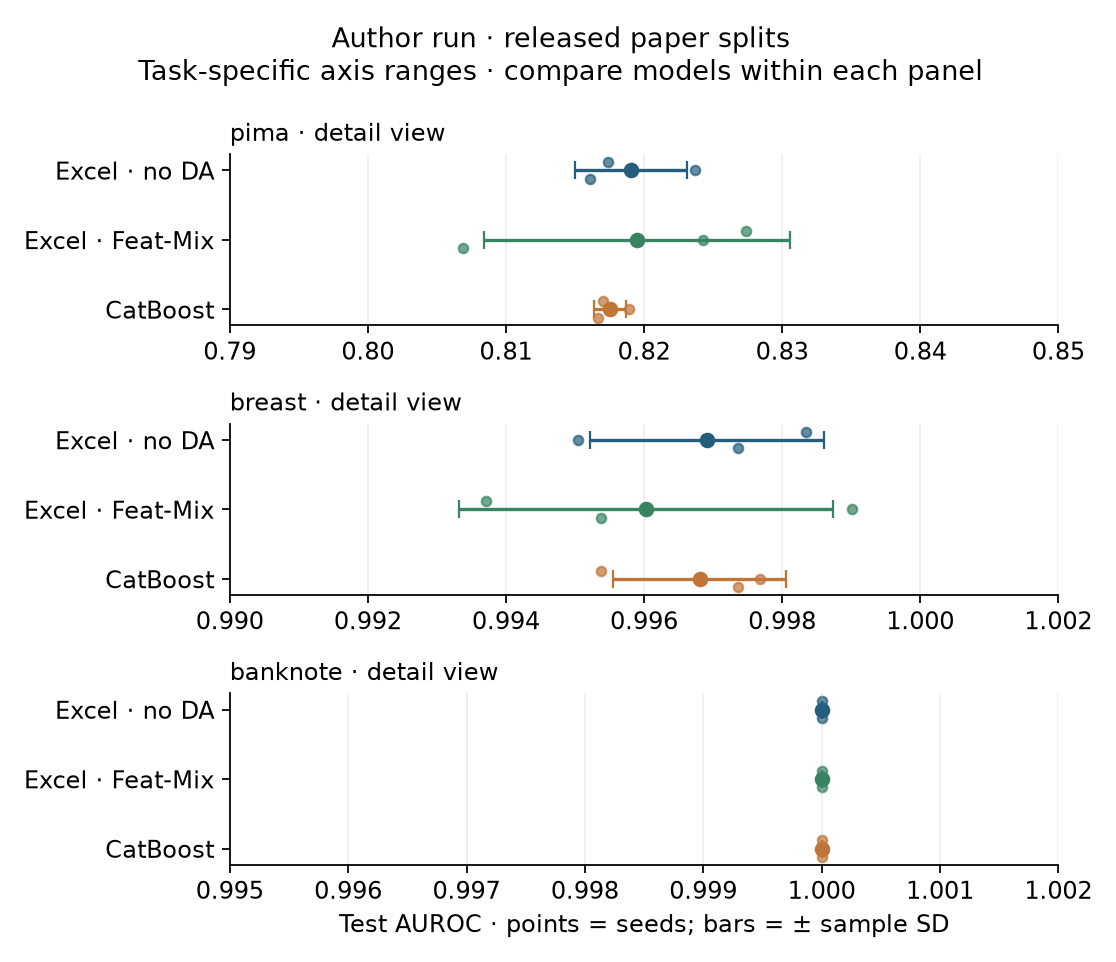

Author-reference test AUROC on three released tasks; seed points and ± sample SD. These are not current kernel outputs.

### PROVIDED — inspect data provenance before training
The authors’ already-prepared arrays are deliberately used unchanged. Their upstream preprocessing fit scope is not independently reconstructed. We fit only the new MI order on training rows. Checksums detect changed downloaded data; they do not prove absence of upstream leakage.

In [ ]:
data=paper_data('pima')
print({k:len(data[k]) for k in ('train','valid','test')})
print('Columns in model order:',[data['meta']['columns'][i] for i in data['meta']['order']])
display(pd.DataFrame(data['x'][:5]))
assert not (set(data['train']) & set(data['test']))
assert data['importance'].tolist()==sorted(data['importance'].tolist(),reverse=True)
print('Declared source:',data['meta']['source'])

### PROVIDED — the comparison harness is visible too
It trains the model defined above. CatBoost is a library baseline; it is not the architecture being taught. The same split is held across arms; these different model families receive explicit fixed budgets, not equal compute or a paper-level search.

In [ ]:
ARMS=('excel_no_da','excel_feat_mix','catboost')
def experiment(data,seeds=(0,1,2),epochs=30,d=32,layers=2,heads=4,lr=.001,batch=64,
               patience=12,dropout=.1,trees=300,device='cpu',model_cls=ExcelFormer,
               train_fn=train_excel,predict_fn=predict_excel,artifact_dir=None):
    torch.set_num_threads(1)
    x,y,tr,va,te=[data[k] for k in ('x','y','train','valid','test')]
    rows,losses,diagnostics=[],[],{}
    if artifact_dir is not None:
        artifact_dir=Path(artifact_dir);artifact_dir.mkdir(parents=True,exist_ok=True)
    for seed in seeds:
        auc,logs={},{}
        for arm in ARMS:
            if arm=='catboost':
                model=CatBoostClassifier(iterations=trees,depth=6,learning_rate=.05,random_seed=seed,
                    thread_count=1,verbose=False,allow_writing_files=False,eval_metric='Logloss')
                model.fit(x[tr],y[tr],eval_set=(x[va],y[va]),use_best_model=True)
                p=model.predict_proba(x[te])[:,1]
                diagnostics[f'{seed}/{arm}']={'selected_trees':int(model.tree_count_)}
                if artifact_dir is not None: model.save_model(str(artifact_dir/f'{seed}-{arm}.cbm'))
            else:
                torch.manual_seed(seed)
                model=model_cls(x.shape[1],d=d,layers=layers,heads=heads,dropout=dropout)
                model,hist=train_fn(model,x,y,tr,va,seed=seed,epochs=epochs,lr=lr,batch=batch,
                    patience=patience,augmentation=arm=='excel_feat_mix',importance=data['importance'],device=device)
                p=predict_fn(model,x[te])
                diagnostics[f'{seed}/{arm}']={'history':hist,'parameters':sum(p.numel() for p in model.parameters())}
                if artifact_dir is not None: torch.save(model.state_dict(),artifact_dir/f'{seed}-{arm}.pt')
            auc[arm]=float(roc_auc_score(y[te],p));logs[arm]=float(log_loss(y[te],p,labels=[0,1]))
            diagnostics[f'{seed}/{arm}']['test_probabilities']=p.tolist()
        rows.append(auc);losses.append(logs)
    return {'auroc':rows,'log_loss':losses,'diagnostics':diagnostics,'protocol':data['meta']}

In [ ]:
# CHECK — prove that training reaches your function, not a packaged replacement.
original_spa=spa_attention
calls={'count':0}
def counted_spa(*args,**kwargs):
    calls['count']+=1
    return original_spa(*args,**kwargs)
spa_attention=counted_spa
try:
    torch.manual_seed(0)
    smoke=ExcelFormer(data['x'].shape[1],d=16,heads=2,layers=1,dropout=0)
    smoke,_=train_excel(smoke,data['x'],data['y'],data['train'],data['valid'],epochs=1)
finally:
    spa_attention=original_spa
assert calls['count']>0,'Training bypassed your attention implementation.'
print('Live student attention calls:',calls['count'])

### Run the three-task experiment
Before execution, predict where augmentation may help and why the tiniest test set may saturate. Changing that prediction after seeing the scores is not evidence of foresight. Seeds measure initialization/training variability on fixed splits, not population uncertainty.

In [ ]:
# PROVIDED — measured outputs from YOUR current code.
local={}
for name in ('pima','breast','banknote'):
    local[name]=experiment(paper_data(name),model_cls=ExcelFormer,train_fn=train_excel,predict_fn=predict_excel)
    print('Finished',name)
summary=summarize({k:v['auroc'] for k,v in local.items()},ARMS)
def summary_table(summary):
    return pd.DataFrame({ds:{m:f"{v['mean']:.4f} ± {v['sample_std']:.4f}" for m,v in models.items()}
                         for ds,models in summary['per_dataset'].items()}).T
display(summary_table(summary))
print('Mean ranks:',summary['mean_ranks'],'Friedman:',summary.get('friedman'),'CD:',summary.get('nemenyi_cd'))

In [ ]:
# CHECK — local reproducibility against author evidence on this software environment.
author=json.loads(Path('_verify_l049_results.json').read_text())
same_versions=environment()['versions']==author['environment']['versions']
max_score_change=max(abs(summary['per_dataset'][ds][m]['mean']-author['summary']['per_dataset'][ds][m]['mean']) for ds in local for m in ARMS)
print('Same recorded versions:',same_versions,'max mean AUROC change:',max_score_change)
if same_versions:
    assert max_score_change<1e-6,'Inspect student code / protocol before interpreting changed rankings.'
# Different package versions may produce different scores; document them, do not overwrite the ledger.
print('CHECK 5: evidence computed; compare full protocol, not one rounded score.')

## 8. Change the deployment question: predict later events




A random split asks about another observation mixed with the observed period. A **temporal split** trains on earlier observations, selects settings on a later validation interval, and evaluates on the latest interval. It changes the target population and often entity coverage. It is not just a more difficult version of the identical statistical question.




Our separate transfer probe reuses the real MovieLens-1M timestamps from L048. Remove rating 3; labels are zero for 1–2 and one for 4–5. Sample 12,000 events without consulting their labels using seed 49. The random regime uses stratified 64/16/20 splits with seed 49. The temporal regime assigns whole timestamp groups around the 64% and 80% time quantiles, so no timestamp straddles a boundary.




Inputs are age and training-only category frequencies for user, movie, gender, occupation and ZIP. A frequency is the share of training events with that category; unseen categories map to zero. Quantile transformation and MI ordering fit only the corresponding training partition. Category IDs are never treated as measured magnitudes. Ratings and timestamps are excluded from inputs. We use the dataset’s demographic snapshot; its exact historical availability is not verified, so this is a time-transfer demonstration, not a certified production point-in-time dataset.




Frequency encoding deliberately loses category identity and is not the paper’s target encoder. Both regimes use the same events, model budgets and feature-building rule, but fit their transforms independently on the proper training rows. Their test sets differ. A score change therefore combines distribution, composition, representation and fitted-model effects; it is not a paired causal estimate of “the effect of time.”







| Task | Excel · no DA | Excel · Feat-Mix | CatBoost |
| --- | --- | --- | --- |
| random | 0.6751 ± 0.0040 | 0.6708 ± 0.0020 | 0.6862 ± 0.0029 |
| temporal | 0.6755 ± 0.0022 | 0.6750 ± 0.0028 | 0.6692 ± 0.0012 |





Here CatBoost leads under random splitting, while the neural arms lead on the later interval. This is a measured ranking reversal for our fixed pipeline, not a universal temporal advantage. Excel no DA barely changes in mean AUROC; a temporal split does not mechanically lower every model’s score.





Do not add random and temporal MovieLens as two independent datasets to the three-task Friedman analysis. They share an underlying source. A result here says something about our transferred pipeline; it cannot refute or reproduce either paper’s original benchmark.

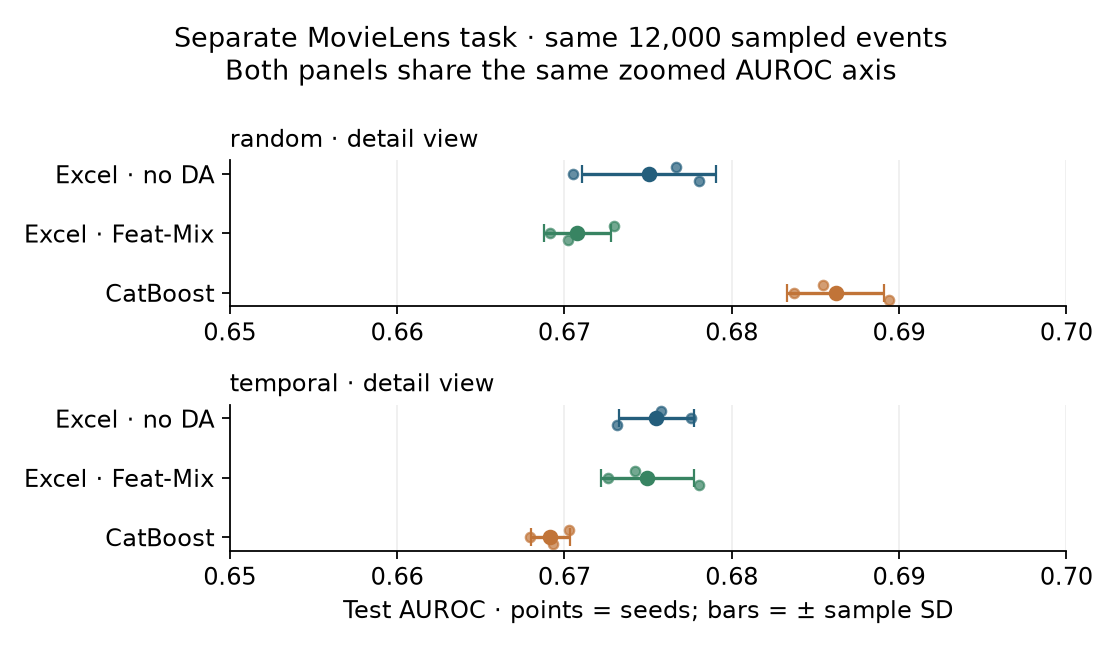

Author-reference MovieLens transfer results; random and chronological test populations differ. These are not two independent benchmark datasets.

In [ ]:
# PROVIDED — replay time transfer with the same live implementation.
transfer={}
for kind in ('random','temporal'):
    frame=temporal_data(kind)
    ranges=frame['meta']['timestamp_ranges']
    if kind=='temporal':
        assert ranges['train'][1]<ranges['valid'][0]<ranges['test'][0], 'Timestamp groups crossed partitions.'
    transfer[kind]=experiment(frame,model_cls=ExcelFormer,train_fn=train_excel,predict_fn=predict_excel)
    print(kind,ranges)
transfer_summary=summarize({k:v['auroc'] for k,v in transfer.items()},ARMS)
display(summary_table(transfer_summary))
assert transfer['random']['protocol']['row_ids']==transfer['temporal']['protocol']['row_ids']
print('Same sampled events. Different test populations: do not call the score difference a paired causal effect.')

### EXIT — write a claim audit
Fill the four fields below using your evidence. The automatic check can verify that you supplied an answer; it cannot grade your reasoning. Paste the printed ticket to your teacher for feedback. A loss or INCOMPARABLE verdict is acceptable; inventing a replicated claim is not.

In [ ]:
# TODO — your written audit; retain the dictionary keys.
audit = {
    'paper_claim': '____',
    'local_scope': '____',
    'temporal_limit': '____',
    'reproduction_verdict': '____',
}

In [ ]:
# CHECK / EXIT — content is reviewed by the teacher, not automatically scored.
assert all(isinstance(v,str) and '____' not in v and len(v.split())>=8 for v in audit.values()), 'Supply your own supported explanations.'
ticket={'lesson':49,'audit':audit,'local_summary':summary,'transfer_summary':transfer_summary,
        'environment':environment(),'trompt_probe':trompt_run,'full_trompt_benchmark':'NOT_RUN'}
Path('data/cache/l049-exit.json').write_text(json.dumps(ticket,indent=2))
print(json.dumps(ticket,indent=2))

## 9. Move closer to the paper, then keep the ledger honest




The next step uses the *same visible implementation*, the authors’ Pima split, d=256, 32 heads, three blocks, dropout 0.3 and learning rate 0.0001. The closer preset caps training at 100 epochs with patience 32, uses batches of 256, and allows 1,000 CatBoost trees. The longer `paper` preset raises the caps to 1,000 epochs and 4,096 trees; its name describes a capacity/budget option, not completed paper replication. Neither runs the paper’s tuning search.




The specific cited target is the appendix row **Pima-Indians-Diabetes**: Feat-Mix default AUROC 0.8356 and tuned CatBoost 0.7528. Other similarly named Pima rows have different scores. These are the authors’ reported five-run results, not our outputs. [ExcelFormer Appendix G](https://arxiv.org/html/2301.02819v5#A7).







| Task | Excel · no DA | Excel · Feat-Mix | CatBoost |
| --- | --- | --- | --- |
| pima | 0.8383 ± 0.0099 | 0.8261 ± 0.0057 | 0.8175 ± 0.0012 |





**Larger-run verdict: INCOMPARABLE.** Width, depth and attention heads align more closely with the paper, but a single released split, chosen epoch cap and batch size, augmentation sampling details and absent hyperparameter search prevent an exact table reproduction. Selected weights, predictions and histories are saved under `labs/data/cache/l049-closer/`; regenerate them with the runner.





**Conclusion ledger:** verified here = specified forward path, equation probes, and measured local runs; paper claim = cited benchmark results; scale-up = the larger Pima attempt with its own configuration and artifacts. A close score with a different protocol remains **INCOMPARABLE** as an exact reproduction. It may be numerically close; that is a different sentence.




The lab includes a gated Colab next step and [a Modal T4 operator](../modal/l049_paper_repro.py). Both use the same runner, save selected weights and predictions, resume completed seeds, and reject incompatible cached runs. The 96/21-task ExcelFormer suite, its tuning search, and the full Trompt benchmark remain **NOT_RUN**.

### NEXT STEP — run closer to the paper
The loop below reuses the same model and training functions you just read. Set the gate to True on a suitable runtime. `smoke` verifies the operator quickly; `closer` uses width 256 / 3 blocks / 32 heads on Pima; `paper` increases caps but still does not run the published suite or tuning search. Keep those gaps in the verdict.

The output directory stores a contract, per-seed results, predictions and selected weights. Use a fresh directory after implementation or protocol changes. For unattended GPU execution: `modal run --detach modal/l049_paper_repro.py --preset closer` from the repository root. No cloud job has been launched by authoring this lesson.

In [ ]:
# PROVIDED — explicit presets
PRESETS={
    'smoke':dict(epochs=2,d=16,layers=1,heads=2,lr=.001,batch=256,patience=2,dropout=.1,trees=20),
    'closer':dict(epochs=100,d=256,layers=3,heads=32,lr=.0001,batch=256,patience=32,dropout=.3,trees=1000),
    'paper':dict(epochs=1000,d=256,layers=3,heads=32,lr=.0001,batch=256,patience=32,dropout=.3,trees=4096)}

In [ ]:
# PROVIDED — resumable closer-to-paper runner
def run(preset='closer',out='data/cache/l049-closer',device=None,model_cls=ExcelFormer,
        train_fn=train_excel,predict_fn=predict_excel,attention_fn=spa_attention,mix_fn=feat_mix):
    """Resume only identical source/config/data/device runs. Keep the student's code live."""
    cfg=PRESETS[preset];folder=Path(out);folder.mkdir(parents=True,exist_ok=True)
    data=paper_data('pima');device=device or ('cuda' if torch.cuda.is_available() else 'cpu')
    # Notebook execution filenames/cell numbers change across kernel restarts.
    # Reuse the course's semantic code hash rather than source availability or
    # marshal metadata. The Colab bootstrap clones labs/, including this helper.
    from _live_identity_l051 import code_fingerprint
    identities=[]
    dependencies=model_cls.__init__.__globals__
    for obj in (model_cls,dependencies['GatedTokenizer'],dependencies['SPABlock'],
                train_fn,predict_fn,attention_fn,mix_fn):
        funcs=([(name,fn) for name,fn in vars(obj).items() if inspect.isfunction(fn)]
               if inspect.isclass(obj) else [(obj.__name__,obj)])
        identities.append({name:code_fingerprint(fn) for name,fn in funcs})
    contract={'preset':preset,'config':cfg,'data':data['meta'],'environment':environment(),
              'device':device,'implementation_identity':'semantic-code-v1','implementation':identities}
    digest=hashlib.sha256(json.dumps(contract,sort_keys=True).encode()).hexdigest()
    contract_path=folder/'contract.json'
    if contract_path.exists():
        assert json.loads(contract_path.read_text())['digest']==digest,'Changed implementation/protocol: choose a fresh output folder.'
    else: contract_path.write_text(json.dumps({'digest':digest,'contract':contract},indent=2))
    rows=[];seeds=(0,) if preset=='smoke' else (0,1,2)
    for seed in seeds:
        path=folder/f'seed-{seed}.json'
        if path.exists(): r=json.loads(path.read_text())
        else:
            r=experiment(data,seeds=(seed,),device=device,model_cls=model_cls,train_fn=train_fn,predict_fn=predict_fn,
                         artifact_dir=folder/'weights',**cfg)
            path.write_text(json.dumps(r,indent=2))
        rows.extend(r['auroc'])
        print('completed seed',seed,flush=True)
    result={'preset':preset,'summary':summarize({'pima':rows},ARMS),'contract_sha256':digest,
            'environment':environment(),'paper_target':{'table':'ExcelFormer v5 Table 14, Pima-Indians-Diabetes','feat_mix_auroc':.8356,'catboost_tuned_auroc':.7528},
            'verdict':'INCOMPARABLE','gaps':['One released split versus published five-run mean.',
            'Chosen batch size/epoch cap; no paper hyperparameter search.',
            'Our per-row Bernoulli Feat-Mix sampler is a documented implementation choice; source augmentation parity not established.',
            'Published upstream preprocessing fit scope is not reconstructed.',
            'Single dataset; the 96/21-table suites and full Trompt benchmark remain NOT_RUN.']}
    (folder/'summary.json').write_text(json.dumps(result,indent=2))
    return result

In [ ]:
# NEXT STEP — gated OFF until you choose a runtime and output directory.
RUN_PAPER_REPRO = False
PAPER_PRESET = 'closer'
PAPER_OUT = 'data/cache/l049-student-closer'
if RUN_PAPER_REPRO:
    paper_result=run(PAPER_PRESET,PAPER_OUT,model_cls=ExcelFormer,train_fn=train_excel,
                     predict_fn=predict_excel,attention_fn=spa_attention,mix_fn=feat_mix)
    display(summary_table(paper_result['summary']))
    print(paper_result['verdict'],paper_result['gaps'])
else:
    print('Current student scale-up: NOT_RUN. Author larger run is a separate snapshot.')

### NEXT STEP — Trompt capacity check, with benchmark gaps kept visible
The gate below increases the numeric Trompt model to the paper's d=P=128 and L=6. It still uses Pima from ExcelFormer's release, a chosen optimizer and validation-loss selection. This is a capacity/execution step, **INCOMPARABLE**, not Grinsztajn45 reproduction. Before making the paper's performance claim, use its Appendix A dataset IDs/splits, preprocessing, accuracy/R² metrics and 40-configuration search accounting; categorical encoding and original optimizer parity remain outstanding.

Local CLI equivalent: `.venv/bin/python labs/_verify_trompt_l049.py --capacity --device cuda --out /tmp/l049-trompt-capacity.json`. This operator does not launch a cloud job.

In [ ]:
# NEXT STEP — off by default; runs YOUR complete numeric Trompt path.
RUN_TROMPT_CAPACITY = False
if RUN_TROMPT_CAPACITY:
    capacity_run=probe(d=128,prompts=128,layers=6,epochs=100,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        model_cls=Trompt,train_fn=train_trompt,predict_fn=predict_trompt)
    Path('data/cache/l049-trompt-capacity.json').write_text(json.dumps(capacity_run,indent=2))
    print(capacity_run['verdict'],capacity_run['summary'])
else:
    print('Trompt capacity run: NOT_RUN; Grinsztajn45 reproduction: NOT_RUN.')

**Ask a follow-up.** Explain any unclear arrow, tensor axis, source discrepancy, seed interval or claim boundary. Bring your EXIT ticket; completion alone does not establish mastery of every introduced term. Next lesson is the Q1 fair-comparison checkpoint.